In [1]:
import sys
import os

from instant_aiv.models.NNpp import *
from instant_aiv.models.metrics import *
from instant_aiv.manage.plots import *
from instant_aiv.manage.dataloader import *


# Libraries
import argparse
import numpy as np
import scipy.io
import time
import gc
import pandas as pd
import pickle


#Plots
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm


import os
import numpy as np
import jax
from jax import jit, grad, vmap, value_and_grad,jvp

import jax.numpy as jnp
import optax

from typing import Tuple
import time


import h5py
from typing import List, Dict
from pyDOE import lhs
import tqdm


In [2]:
cmap = 'plasma'
num_colors=8
# Create a colormap
cmap = plt.get_cmap(cmap)
colors = [cmap(i) for i in np.linspace(0, 1, num_colors)]
colors=colors[:num_colors//4]+colors[3*num_colors//4:]
print(len(colors))
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
mpl.rcParams['font.size'] = 20

4


# Tunning Parameters

In [3]:
parser = argparse.ArgumentParser(description='Tunning_parameters')
parser.add_argument('--run_type'   , type=str  , default='Concentration_Pressure')
parser.add_argument('--mode'       , type=str  , default='Initialization')
parser.add_argument('--Run_MODE'   , type=str  , default='Train')

parser.add_argument('--num_layer'  , type=int  , default=8)
parser.add_argument('--width_layer', type=int  , default=200)
parser.add_argument('--train_ratio' , type=float, default=0.5)
parser.add_argument('--Weight_Norm'    , type=int , default=1)
parser.add_argument('--Mod_MLP'    , type=int , default=0)
parser.add_argument('--Use_ResNet'    , type=int , default=1)
parser.add_argument('--Adaptive'    , type=int , default=1)
parser.add_argument('--Light'    , type=int , default=0)
parser.add_argument('--mode_POD'  , type=int  , default=5)
parser.add_argument('--offset_k' , type=float  , default=1.0)


parser.add_argument('--batch_size' , type=int  , default=10000)
parser.add_argument('--num_gsteps' , type=int  , default=100*(10**3))
parser.add_argument('--Name' , type=str  , default='Init_c_and_p')
parser.add_argument('--normalization' , type=str  , default='chebyshev5')
parser.add_argument('--Equal_Batch' , type=bool  , default=True)
parser.add_argument('--optimizer' , type=str  , default='AdamW')

parser.add_argument('--use_RBA'    , type=int , default=1)
parser.add_argument('--k_samp' , type=float  , default=2.0)
parser.add_argument('--c_samp' , type=float  , default=0.5)
parser.add_argument('--lr_lambdas_0' , type=float  , default=0.1)
parser.add_argument('--gamma' , type=float  , default=0.999)


parser.add_argument('--use_mass'    , type=int , default=1)



args, unknown = parser.parse_known_args()
for arg, value in vars(args).items():
    print(f'{arg}: {value}')

run_type: Concentration_Pressure
mode: Initialization
Run_MODE: Train
num_layer: 8
width_layer: 200
train_ratio: 0.5
Weight_Norm: 1
Mod_MLP: 0
Use_ResNet: 1
Adaptive: 1
Light: 0
mode_POD: 5
offset_k: 1.0
batch_size: 10000
num_gsteps: 100000
Name: Init_c_and_p
normalization: chebyshev5
Equal_Batch: True
optimizer: AdamW
use_RBA: 1
k_samp: 2.0
c_samp: 0.5
lr_lambdas_0: 0.1
gamma: 0.999
use_mass: 1


In [4]:
Run_type = args.run_type
Mode=args.mode
#ResNet Architecures
Use_ResNet=args.Use_ResNet 
Adaptive=args.Adaptive 
Light=args.Light 
num_layer=args.num_layer
use_mass=args.use_mass 
offset_k=args.offset_k 
args.Name=args.Name+str(offset_k)
if Use_ResNet:
    num_layer=int((num_layer+2)/2)

width_layer=args.width_layer
layers={
    'P' :[4]  + num_layer*[3*width_layer//4] + [1],
    'c' :[4]  + num_layer*[width_layer] + [1],
    'c_std' :[4]  + num_layer*[width_layer//3] + [1],
    'k' :[4]  + num_layer*[3*width_layer//4] + [1],
    'D' :[4]  + num_layer*[3*width_layer//4] + [1],
}
layers_ref=np.copy(layers['P'])
layers_1=np.copy(layers['P'])

train_ratio=args.train_ratio

Details=f'{args.Name}-Train:{train_ratio}_mass:{args.use_mass}'

Run_MODE=args.Run_MODE

print('Model Architecture:')
print(layers)

activation = 'sin'
initialization = 'xavier'
normalization  = args.normalization
loss_metric ='L2'
Weight_Norm =args.Weight_Norm#Weight Normalization
use_RBA=args.use_RBA
Mod_MLP=args.Mod_MLP  #Modified MLP
normalize_outputs=False
init_zero=True

#Optimization
num_gsteps  = args.num_gsteps
batch_size = args.batch_size

#learning 
lam_min=0.0
lr0=2*10**(-3)
lrf=1*10**(-4)
lr_lambdas_0=args.lr_lambdas_0
gamma=args.gamma
max_lambda=lr_lambdas_0/(1-gamma)
print(f'Max lambdas will be:{max_lambda}')
T_e=num_gsteps
decay_rate=0.9
decay_step=0
seed_np=1234
key = jax.random.PRNGKey(seed_np)
key, subkey = jax.random.split(key)
# File Name
dataset_name = f'{Details}_RBA:{use_RBA}'
#Scaling factor
p_scale=10

#Sample Points
N_r=1000000
N_d=1000000



Model Architecture:
{'P': [4, 150, 150, 150, 150, 150, 1], 'c': [4, 200, 200, 200, 200, 200, 1], 'c_std': [4, 66, 66, 66, 66, 66, 1], 'k': [4, 150, 150, 150, 150, 150, 1], 'D': [4, 150, 150, 150, 150, 150, 1]}
Max lambdas will be:99.99999999999991


In [5]:
project_root = find_package_directory() # if error please define the root package directly (e.g. project_root='/users/.../' )

data_path=project_root+'/Data/Synthetic_Data/Realistic.csv'

out_BCs_path=project_root+"/Data/Synthetic_Data/BC_noflow.csv"

inlet1_path=project_root+"/Data/Synthetic_Data/BC_inlet.csv"

outlet1_path=project_root+"/Data/Synthetic_Data/BC_outlet2.csv"

outlet2_path=project_root+"/Data/Synthetic_Data/BC_outlet3.csv"

save_path=project_root+f'/Results/{Run_type}/'
big_data_path=save_path
print(f'Analizing:{data_path}')
print(f'Details:{Details}')
print(f'dataset_name:{dataset_name}')

Analizing:/oscar/data/gk/jdtoscan/References/MR-AVI//Data/Synthetic_Data/Realistic.csv
Details:Init_c_and_p1.0-Train:0.5_mass:1
dataset_name:Init_c_and_p1.0-Train:0.5_mass:1_RBA:1


In [6]:
use_RBA=int(use_RBA)
print(f'Using RBA:{use_RBA}')

Using RBA:1


## Settings


In [7]:
# Fetching activation function
activation_fn = ACTIVATION_FUNCTIONS.get(activation.lower())

# Fetching normalization functions and metrics
norm_settings = NORMALIZATION_FUNCTIONS.get(normalization.lower())
norm_fn = norm_settings['fn']
Norm_metric1 = norm_settings['metric1']
Norm_metric2 = norm_settings['metric2']

# Fetching error function
Error_fn = ERROR_FUNCTIONS.get(loss_metric.lower())

#Adjust layer structure to account for Chebyshev Feature Embbeding
for key in layers.keys():
    embed_size=layers[key][1]
    input_dim=layers[key][0]*5
    output_dim=layers[key][-1]
    layers[key]=[input_dim]+(num_layer)*[embed_size]+ [output_dim]
print(f'New architecture:{layers}')


New architecture:{'P': [20, 150, 150, 150, 150, 150, 1], 'c': [20, 200, 200, 200, 200, 200, 1], 'c_std': [20, 66, 66, 66, 66, 66, 1], 'k': [20, 150, 150, 150, 150, 150, 1], 'D': [20, 150, 150, 150, 150, 150, 1]}


In [8]:
np.random.seed(seed_np)
params= init_params_dict(layers, initialization,Use_ResNet)

# Model selection
pinn_fn =select_model(WN=Weight_Norm,Use_ResNet=Use_ResNet,Adaptive=Adaptive,Light=Light)
print(f'The model will be: {pinn_fn}')

You selected: Network mlp with degree(if KAN) 5, initialization xavier,Use_ResNet 1


The model will be: <function WN_ResNet_adaptive at 0x7fd666090ca0>


### Load Permeability Model

In [9]:
save_file_details=project_root+'Results/Permeability_Details.pkl'# This file should be generated in the previous step by running Init_K.py
with open(save_file_details, 'rb') as f:
    file_details_loaded = pickle.load(f)
print(file_details_loaded.keys())


dict_keys(['path', 'name', 'M1', 'M2', 'layers', 'lb_all', 'ub_all', 'off_set', 'k_char0'])


In [10]:
M1_all={}
M2_all={}
lb_all={}
ub_all={}
off_set={}
Norm_fn={}
Norm_fn['c']=norm_fn
Norm_fn['P']=norm_fn

layers_k=file_details_loaded['layers']
M1_all['k']=file_details_loaded['M1']
M2_all['k']=file_details_loaded['M2']
lb_all['k']=file_details_loaded['lb_all']
ub_all['k']=file_details_loaded['ub_all']
off_set['k']=file_details_loaded['off_set']
Norm_fn['k']=Encode_Chebysev_5


k_char0=file_details_loaded['k_char0']
k_params_file=project_root+file_details_loaded['path']
dataset_k=file_details_loaded['name']
loaded_params_k = load_params_dict(k_params_file, dataset_k, layers_k, initialization,type='Final',Use_ResNet=Use_ResNet) 
print('Parameters loaded from file')
params['k']=loaded_params_k['k']
layers['k']=layers_k['k']

100%|██████████| 1/1 [00:00<00:00, 43.68it/s]

Initializing:mlp parameters.


Parameters loaded from file


In [11]:
# Define separate optimizers
optimizer={}
opt_state={}
for key in layers.keys():
    print(f'Initializing Optimizer for:{key}')
    optimizer[key],decay_step= initialize_optimizer(lr0, decay_rate, lrf, decay_step, num_gsteps,optimizer_type=args.optimizer)
    opt_state[key]=optimizer[key].init(params[key])
M1= Norm_metric1
M2= Norm_metric2
print('Norm metrics:',M1,M2)


Initializing Optimizer for:P
Optimizer adamw
Weight decay: 1e-05
The decay step will be 3517.020415607157
Initializing Optimizer for:c
Optimizer adamw
Weight decay: 1e-05
The decay step will be 3517.020415607157
Initializing Optimizer for:c_std
Optimizer adamw
Weight decay: 1e-05
The decay step will be 3517.020415607157


Initializing Optimizer for:k
Optimizer adamw
Weight decay: 1e-05
The decay step will be 3517.020415607157
Initializing Optimizer for:D
Optimizer adamw
Weight decay: 1e-05
The decay step will be 3517.020415607157
Norm metrics: <function <lambda> at 0x7fd667d21ca0> <function <lambda> at 0x7fd667d21d30>


## Create Folders

In [12]:
subdirs = ["General","Imgs", "Big_Data", "Data", "Flow_rate", "Errors"]
paths = create_and_return_directories(save_path, dataset_name, subdirs)
print(dataset_name)
result_path = paths["General"]
images_path = paths["Imgs"]
big_path = paths["Big_Data"]
Video_path = paths["Flow_rate"]
errors_path = paths["Errors"]


The general path is: /oscar/data/gk/jdtoscan/References/MR-AVI//Results/Concentration_Pressure/Init_c_and_p1.0-Train:0.5_mass:1_RBA:1/General/
The imgs path is: /oscar/data/gk/jdtoscan/References/MR-AVI//Results/Concentration_Pressure/Init_c_and_p1.0-Train:0.5_mass:1_RBA:1/Imgs/
The big data path is: /oscar/data/gk/jdtoscan/References/MR-AVI//Results/Concentration_Pressure/Init_c_and_p1.0-Train:0.5_mass:1_RBA:1/Big_Data/
The data path is: /oscar/data/gk/jdtoscan/References/MR-AVI//Results/Concentration_Pressure/Init_c_and_p1.0-Train:0.5_mass:1_RBA:1/Data/
The flow rate path is: /oscar/data/gk/jdtoscan/References/MR-AVI//Results/Concentration_Pressure/Init_c_and_p1.0-Train:0.5_mass:1_RBA:1/Flow_rate/
The errors path is: /oscar/data/gk/jdtoscan/References/MR-AVI//Results/Concentration_Pressure/Init_c_and_p1.0-Train:0.5_mass:1_RBA:1/Errors/
Init_c_and_p1.0-Train:0.5_mass:1_RBA:1


# Non-Dimensional values

In [13]:
k1=1*10**(-12)#mm2
D1=3.8*10**(-10)#mm2/s
k2=1*10**(-16)
D2=2.3*10**(-10)
nu_e=7*10**(-7)
rho=993
mu=0.6913e-3
h=0.00034 #Maximum length by 100
L_char=h
U_char=0.5/5#mm/min
D_char=2.4e-10#m2/s
U_char=U_char*(1/1000)*(1/60)#m/s
T_char=L_char/U_char
C_char=1
Pef=U_char*L_char/D_char
mms=10**6
L_char=L_char
k_char=k_char0
P_char=U_char*L_char*mu/k_char
print(T_char,L_char,U_char,C_char,D_char)
print(Pef)
print(k_char)

T_SI=1
L_SI=1000
D_SI=1#10**6
U_SI=1#1000
P_SI=1
K_SI=1#10**6
SI_fact_steady=np.array([1/T_SI,1/L_SI,1/L_SI,1/L_SI,1/D_SI,1/U_SI,1/U_SI,1/U_SI,1/P_SI,1/K_SI])
SI_fact=np.array([1/T_SI,1/L_SI,1/L_SI,1/L_SI,1])
non_dim_fact_steady=np.array([1/T_char,1/L_char,1/L_char,1/L_char,1/D_char,1/U_char,1/U_char,1/U_char,1/P_char,1/k_char])
non_dim_fact=np.array([1/T_char,1/L_char,1/L_char,1/L_char,1])
print(non_dim_fact)

204.00000000000003 0.00034 1.6666666666666667e-06 1 2.4e-10
2.361111111111111
1e-14
[4.90196078e-03 2.94117647e+03 2.94117647e+03 2.94117647e+03
 1.00000000e+00]


## Load Data


In [14]:
df = pd.read_csv(data_path)
all_data = df.to_numpy()


In [15]:
txyzDuvwpk=np.hstack((df['x(mm)'].to_numpy()[:,None],
                      df['x(mm)'].to_numpy()[:,None],
                      df['y(mm)'].to_numpy()[:,None],
                      df['z(mm)'].to_numpy()[:,None],
                      df['D(m^2/s)'].to_numpy()[:,None],
                      df['u(m/s)'].to_numpy()[:,None],
                      df['v(m/s)'].to_numpy()[:,None],
                      df['w(m/s)'].to_numpy()[:,None],
                      df['p(Pa)'].to_numpy()[:,None],
                      df['k(m^2)'].to_numpy()[:,None]))
txyzc=[]
for time_f in tqdm.tqdm(range(90)):
    x_frame=np.hstack((all_data[:,0:1]*0+time_f*60,all_data[:,:3],all_data[:,time_f+9:time_f+10]))
    txyzc.append(x_frame)
txyzc=np.vstack(txyzc)
print(txyzc.shape)
txyzDuvwuvwk=txyzDuvwpk

100%|██████████| 90/90 [00:00<00:00, 217.36it/s]


(36008730, 5)


In [16]:
txyzc = txyzc[~np.isnan(txyzc).any(axis=1)]
c_min=np.min(txyzc[:,4:5])
c_max=np.max(txyzc[:,4:5])
c_norm=(txyzc[:,4:5]-c_min)/(c_max-c_min)
txyzc = np.hstack((txyzc[:,:4],c_norm))
print('Min and max for txyzc',txyzc.shape)
print(txyzc.min(0))
print(txyzc.max(0))
print('Min and max for txyzDuvwuvwk',txyzDuvwuvwk.shape)
print(txyzDuvwuvwk.min(0))
print(txyzDuvwuvwk.max(0))
txyzc=txyzc*SI_fact
txyzDuvwuvwk=txyzDuvwuvwk*SI_fact_steady
print('SI:Min and max for txyzc',txyzc.shape)
print(txyzc.min(0))
print(txyzc.max(0))
print('SI:Min and max for txyzDuvwuvwk',txyzDuvwuvwk.shape)
print(txyzDuvwuvwk.min(0))
print(txyzDuvwuvwk.max(0))
txyzc=txyzc*non_dim_fact
txyzDuvwuvwk=txyzDuvwuvwk*non_dim_fact_steady
print('ND:Min and max for txyzc',txyzc.shape)
print(txyzc.min(0))
print(txyzc.max(0))
print('ND:Min and max for txyzDuvwuvwk',txyzDuvwuvwk.shape)
print(txyzDuvwuvwk.min(0))
print(txyzDuvwuvwk.max(0))


Min and max for txyzc (36008730, 5)
[0.   1.95 3.65 1.35 0.  ]
[5.340e+03 1.695e+01 1.155e+01 1.175e+01 1.000e+00]
Min and max for txyzDuvwuvwk (400097, 10)
[ 1.9500e+00  1.9500e+00  3.6500e+00  1.3500e+00  2.4000e-10 -2.6236e-04
 -1.2123e-03 -1.3345e-03 -1.4162e-09  6.1167e-17]
[1.6950e+01 1.6950e+01 1.1550e+01 1.1750e+01 2.4000e-10 1.2750e-03
 8.0829e-04 1.6865e-04 1.5000e+03 2.2512e-12]
SI:Min and max for txyzc (36008730, 5)
[0.      0.00195 0.00365 0.00135 0.     ]
[5.340e+03 1.695e-02 1.155e-02 1.175e-02 1.000e+00]
SI:Min and max for txyzDuvwuvwk (400097, 10)
[ 1.9500e+00  1.9500e-03  3.6500e-03  1.3500e-03  2.4000e-10 -2.6236e-04
 -1.2123e-03 -1.3345e-03 -1.4162e-09  6.1167e-17]
[1.6950e+01 1.6950e-02 1.1550e-02 1.1750e-02 2.4000e-10 1.2750e-03
 8.0829e-04 1.6865e-04 1.5000e+03 2.2512e-12]
ND:Min and max for txyzc (36008730, 5)
[ 0.          5.73529412 10.73529412  3.97058824  0.        ]
[26.17647059 49.85294118 33.97058824 34.55882353  1.        ]
ND:Min and max for txyzDuvwuvw

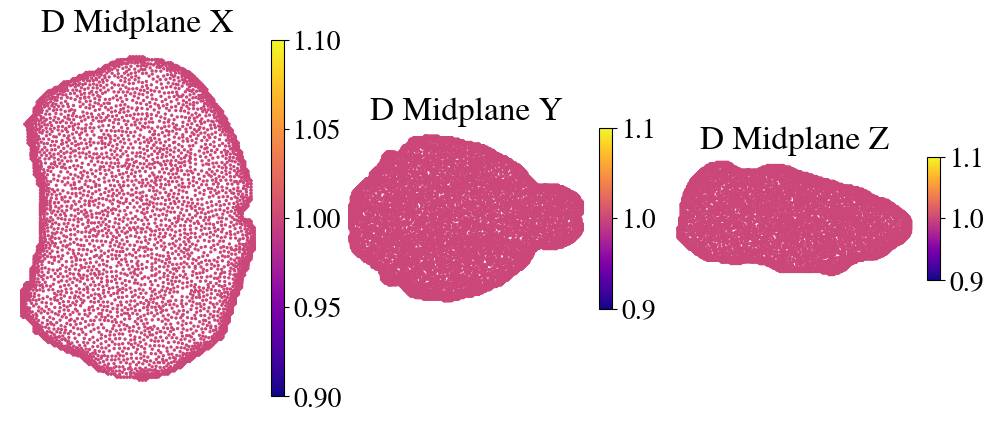

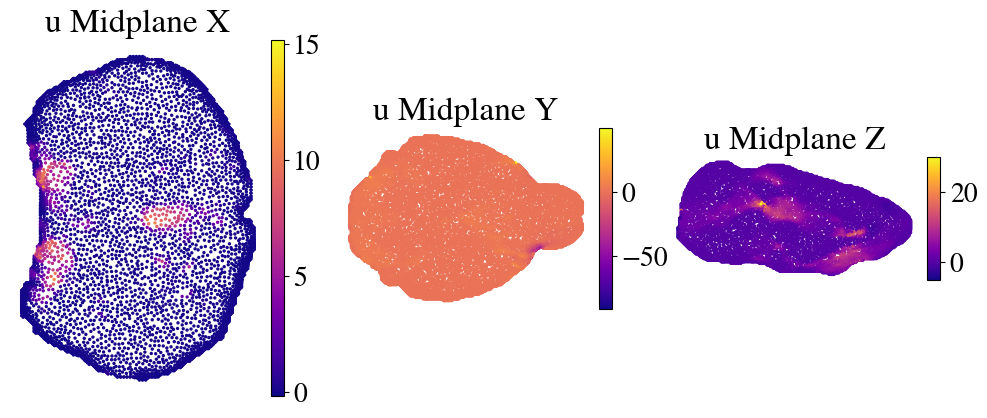

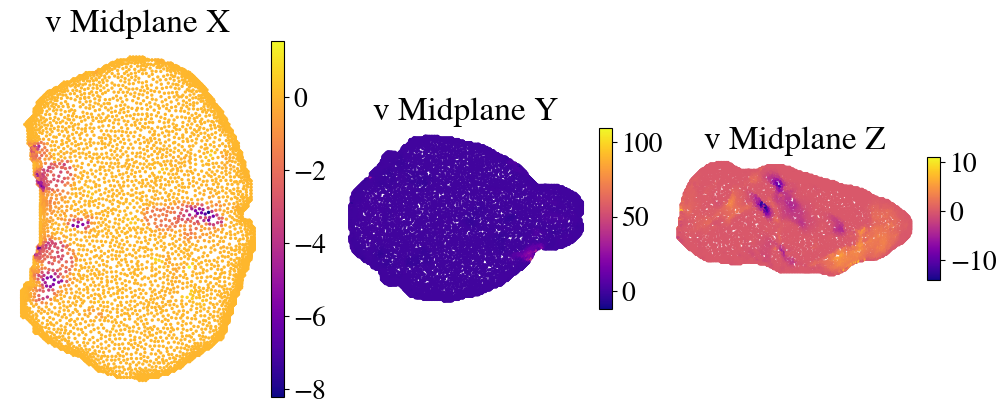

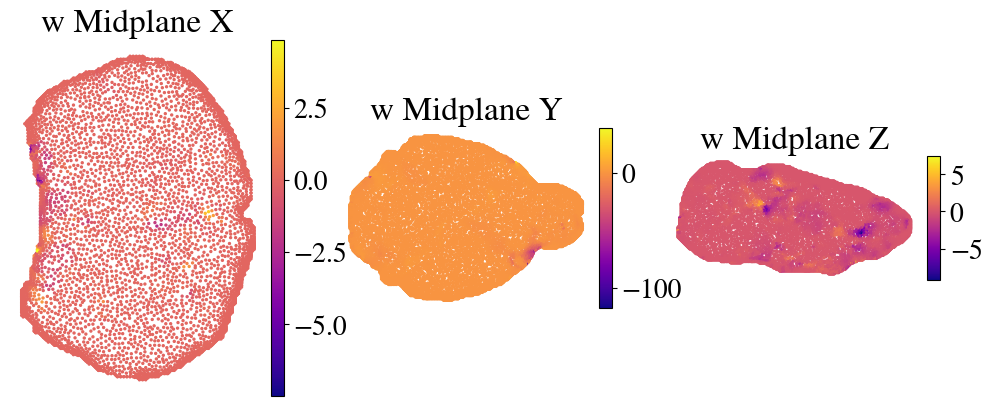

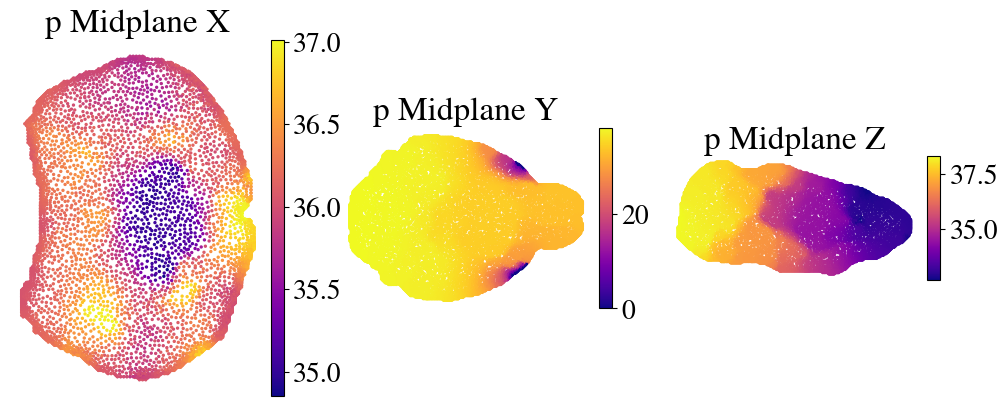

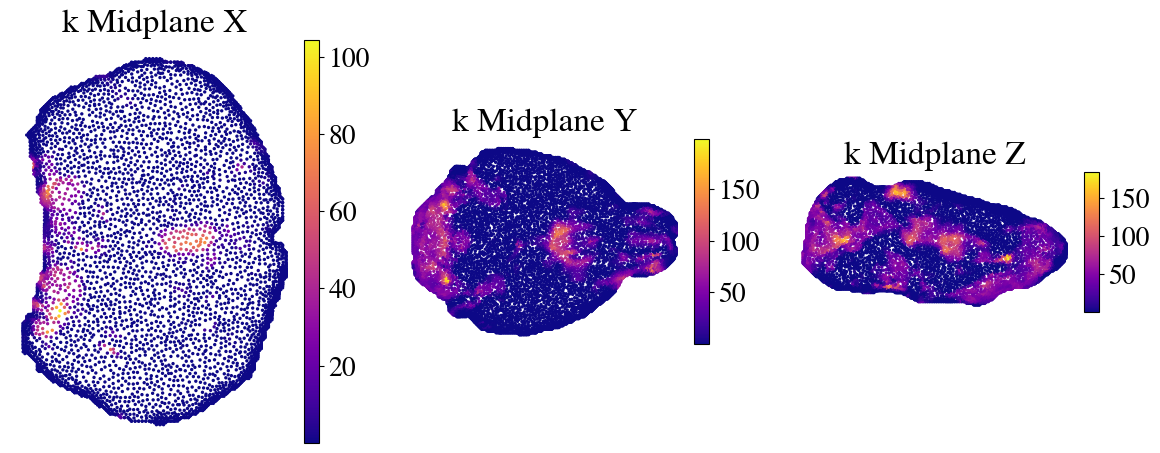

In [17]:
X_plot = txyzDuvwuvwk
t,x, y, z,D, u_gt, v_gt, w_gt,p_gt,k = (X_plot[:,0],
                                            X_plot[:,1],
                                            X_plot[:,2],
                                            X_plot[:,3],
                                            X_plot[:,4],
                                            X_plot[:,5],
                                            X_plot[:,6],
                                            X_plot[:,7],
                                            X_plot[:,8],
                                            X_plot[:,9],)
# Calculate midplane values
x_midplane = np.median(x)
y_midplane = np.median(y)
z_midplane = np.median(z)

tolerance = 0.2  # Adjust based on your dataset's spread

# Define filters for each midplane
x_midplane_filter = np.abs(x - x_midplane) <= tolerance
y_midplane_filter = np.abs(y - y_midplane) <= tolerance
z_midplane_filter = np.abs(z - z_midplane) <= tolerance

# Prepare for visualization

# Variables for plotting
variables = [D,u_gt,v_gt,w_gt,p_gt,k]  # Use the scalar field for coloring
variable_names = ['D','u','v','w','p','k']

# Visualization
for i, var in enumerate(variables):
    fig = plt.figure(figsize=(12, 14))  # Adjust size as needed

    for j in range(3):
        ax = fig.add_subplot(1, 3, j + 1)
        if j == 0:
            filter_mask = x_midplane_filter
            scatter_x, scatter_y = y[filter_mask], z[filter_mask]
            xlabel, ylabel = 'Y', 'Z'
        elif j == 1:
            filter_mask = y_midplane_filter
            scatter_x, scatter_y = x[filter_mask], z[filter_mask]
            xlabel, ylabel = 'X', 'Z'
        else:  # j == 2
            filter_mask = z_midplane_filter
            scatter_x, scatter_y = x[filter_mask], y[filter_mask]
            xlabel, ylabel = 'X', 'Y'

        # Use the scalar field for coloring
        scatter = ax.scatter(scatter_x, scatter_y, c=var[filter_mask], cmap=cmap, s=2)
        ax.set_title(f'{variable_names[i]} Midplane {["X", "Y", "Z"][j]}')
        #ax.set_xlabel(xlabel)
        #ax.set_ylabel(ylabel)
        ax.axis('equal')
        ax.axis('off')  # Change to 'off' if you prefer no axis

        # Adding a colorbar to each subplot
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(scatter, cax=cax)

plt.tight_layout()
plt.show()


In [18]:
X_init_clean=np.hstack((t[:,None],x[:,None],y[:,None],z[:,None],p_gt[:,None]))
X_init_clean = X_init_clean[~np.isnan(X_init_clean).any(axis=1)]
X_permeability=np.hstack((t[:,None],x[:,None],y[:,None],z[:,None],D[:,None],k[:,None]))
X_permeability = X_permeability[~np.isnan(X_permeability).any(axis=1)]

X_test2=np.hstack((t[:,None],x[:,None],y[:,None],z[:,None],u_gt[:,None],v_gt[:,None],w_gt[:,None],p_gt[:,None]))
X_test2 = X_test2[~np.isnan(X_test2).any(axis=1)]


In [19]:
Data=txyzc
all_times=np.unique(Data[:,0:1])
X_nnf=[]
for time_f in tqdm.tqdm(all_times):
    idx_time=np.argwhere(Data[:,0]==time_f).flatten()
    X_frame=Data[idx_time]
    X_nnf.append(X_frame)
X_nnf=np.array(X_nnf)

100%|██████████| 90/90 [00:16<00:00,  5.31it/s]


# Load Bondaries

In [20]:
df_bcs = pd.read_csv(outlet1_path)
X_out = df_bcs.to_numpy()
print(df_bcs.columns)
print(X_out.shape)
non_dim_fact_bcs=np.array(([[1/T_char,1/(1000*L_char),1/(1000*L_char),1/(1000*L_char),
                             1/(1000*L_char), 1/(1000*L_char),1/(1000*L_char),1/P_char
                             ,1/U_char,1/U_char,1/U_char]]))
print(non_dim_fact_bcs.shape)
df_bcs = pd.read_csv(out_BCs_path)
X_out = df_bcs.to_numpy()
print(X_out.shape)
X_out=np.hstack((X_out[:,0:1],X_out[:,:6],X_out[:,6:]))
X_out=X_out*non_dim_fact_bcs
df_bcs = pd.read_csv(outlet1_path)
X_o1 = df_bcs.to_numpy()
X_outlets=np.hstack((X_o1[:,0:1],X_o1[:,:6],X_o1[:,6:]))
X_outlets=X_outlets*non_dim_fact_bcs
df_bcs = pd.read_csv(outlet2_path)
X_o2 = df_bcs.to_numpy()
X_outlets2=np.hstack((X_o2[:,0:1],X_o2[:,:6],X_o2[:,6:]))
X_outlets2=X_outlets2*non_dim_fact_bcs
df_bcs = pd.read_csv(inlet1_path)
X_inlet = df_bcs.to_numpy()
X_inlet=np.hstack((X_inlet[:,0:1],X_inlet[:,:6],X_inlet[:,6:]))
X_inlet=X_inlet*non_dim_fact_bcs
X_in_out=np.vstack((X_inlet,X_outlets))
X_BCs=np.vstack((X_inlet,X_outlets,X_outlets2,X_out))
print(X_BCs.shape)

Index(['X', 'Y', 'Z', 'nx @ t=0', 'ny @ t=0', 'nz @ t=0', 'p (Pa) @ t=0',
       'dl.u (m/s) @ t=0', 'dl.v (m/s) @ t=0', 'dl.w (m/s) @ t=0'],
      dtype='object')
(2786, 10)
(1, 11)
(448051, 10)
(459586, 11)


In [21]:
from scipy.spatial import cKDTree
from sklearn.cluster import DBSCAN
def remove_overlapping_points(base_data, remove_data, tolerance, chunk_size=1000):
    base_coords = base_data[:, 1:4]  # Assuming x, y, z are columns 1, 2, 3
    tree_base = cKDTree(base_coords)

    indices_to_remove = set()
    num_chunks = int(np.ceil(remove_data.shape[0] / chunk_size))

    for i in tqdm.tqdm(range(num_chunks)):
        start_idx = i * chunk_size
        end_idx = min((i + 1) * chunk_size, remove_data.shape[0])
        chunk_remove_coords = remove_data[start_idx:end_idx, 1:4]

        indices = tree_base.query_ball_point(chunk_remove_coords, r=tolerance)
        for sublist in indices:
            indices_to_remove.update(sublist)

    filtered_base_data = np.delete(base_data, list(indices_to_remove), axis=0)
    indices_txyzc_C=list(indices_to_remove)
    all_points=np.arange(len(base_data))
    indices_txyzc = np.setdiff1d(all_points, indices_txyzc_C)   
    return indices_txyzc

## Remove the boundary information (Important)
The PINN model learns using concentration gradient data. However, the numerical method explicitly defines zero normal concentration gradient at the boundaries. This creates an incompatibility, so it's crucial to discard the boundary data, since $\frac{\partial c}{\partial n}|_{boundary}=0$, in these regions.

In [22]:
indices_txyzc=remove_overlapping_points(X_frame,X_BCs,tolerance=1)
indices_xyzuvw=remove_overlapping_points(X_permeability,X_BCs,tolerance=1)
indices_xyzuvw_Crop=remove_overlapping_points(X_permeability,X_BCs,tolerance=1.5)

100%|██████████| 460/460 [00:38<00:00, 12.07it/s]


In [23]:
# Filter steady data
X_permeability=X_permeability[indices_xyzuvw]
X_test_crop=X_test2[indices_xyzuvw_Crop]
X_test2=X_test2[indices_xyzuvw]
# Filter unsteady data
X_nnf=X_nnf[:,indices_txyzc,:]
#Arrays
T_star=X_nnf[:,:,0]
X_star=X_nnf[:,:,1]
Y_star=X_nnf[:,:,2]
Z_star=X_nnf[:,:,3]
C_star=X_nnf[:,:,4]
Xnn=np.concatenate(X_nnf)
X_data_raw=Xnn
X_res=Xnn[:,0:4]
print(Pef)

2.361111111111111


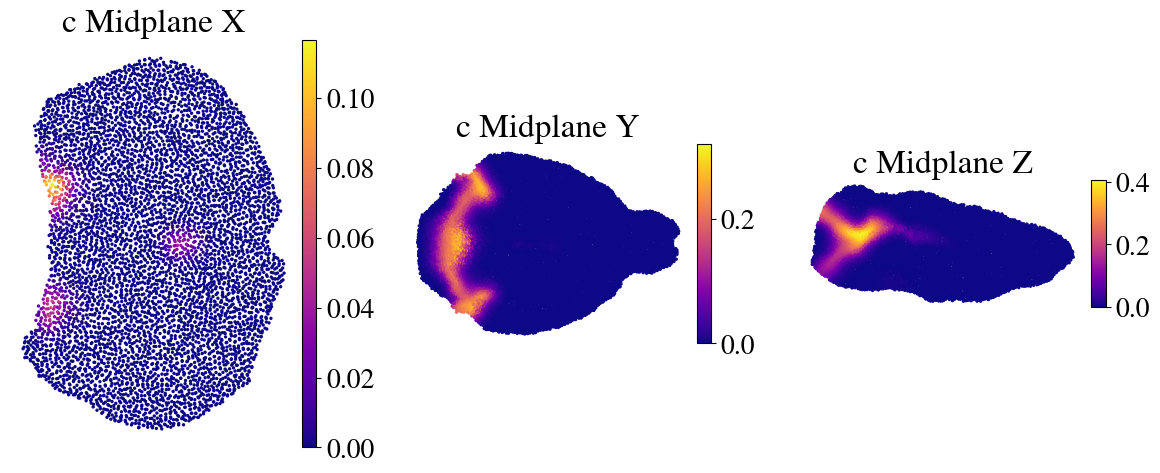

In [24]:
frame=15
X_plot = X_nnf[frame]

t,x, y, z, c = X_plot[:,0], X_plot[:,1], X_plot[:,2], X_plot[:,3], X_plot[:,4]
t2,x2, y2, z2, c2 = X_plot[:,0], X_plot[:,1], X_plot[:,2], X_plot[:,3], X_plot[:,4]

# Calculate midplane values
x_midplane = np.median(x)
y_midplane = np.median(y)
z_midplane = np.median(z)

tolerance = 0.5  # Adjust based on your dataset's spread

# Define filters for each midplane
x_midplane_filter = np.abs(x - x_midplane) <= tolerance
y_midplane_filter = np.abs(y - y_midplane) <= tolerance
z_midplane_filter = np.abs(z - z_midplane) <= tolerance

# Prepare for visualization

# Variables for plotting
variables = [c]  # Use the scalar field for coloring
variable_names = ['c']

# Visualization
for i, var in enumerate(variables):
    fig = plt.figure(figsize=(12, 8))  # Adjust size as needed

    for j in range(3):
        ax = fig.add_subplot(1, 3, j + 1)
        if j == 0:
            filter_mask = x_midplane_filter
            scatter_x, scatter_y = y[filter_mask], z[filter_mask]
            xlabel, ylabel = 'Y', 'Z'
        elif j == 1:
            filter_mask = y_midplane_filter
            scatter_x, scatter_y = x[filter_mask], z[filter_mask]
            xlabel, ylabel = 'X', 'Z'
        else:  # j == 2
            filter_mask = z_midplane_filter
            scatter_x, scatter_y = x[filter_mask], y[filter_mask]
            xlabel, ylabel = 'X', 'Y'

        # Use the scalar field for coloring
        scatter = ax.scatter(scatter_x, scatter_y, c=var[filter_mask], cmap=cmap, s=2)
        ax.set_title(f'{variable_names[i]} Midplane {["X", "Y", "Z"][j]}')
        #ax.set_xlabel(xlabel)
        #ax.set_ylabel(ylabel)
        ax.axis('equal')
        ax.axis('off')  # Change to 'off' if you prefer no axis

        # Adding a colorbar to each subplot
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(scatter, cax=cax)

plt.tight_layout()
plt.show()


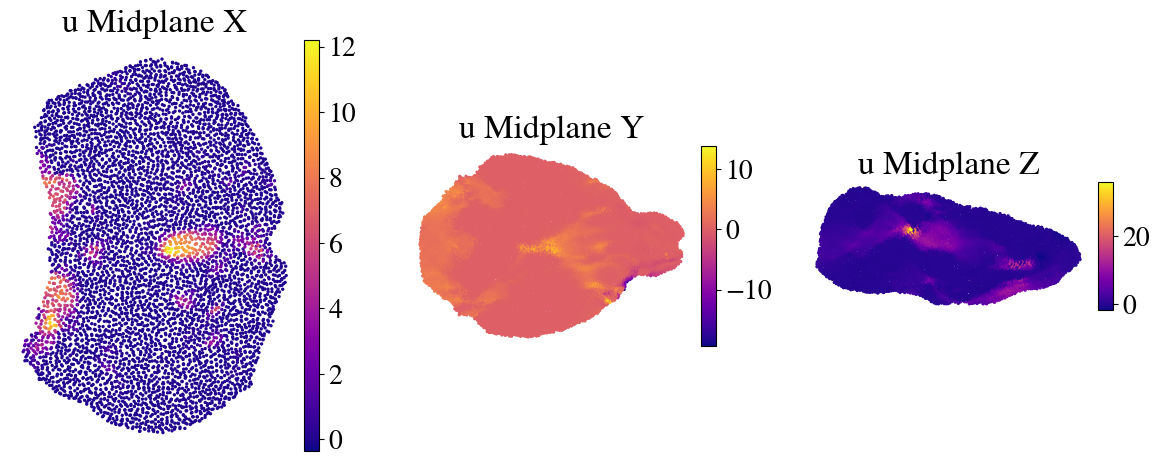

In [25]:
X_plot = X_test2

t,x, y, z, u = X_plot[:,0], X_plot[:,1], X_plot[:,2], X_plot[:,3], X_plot[:,4]
t2,x2, y2, z2, c2 = X_plot[:,0], X_plot[:,1], X_plot[:,2], X_plot[:,3], X_plot[:,4]

# Calculate midplane values
x_midplane = np.median(x)
y_midplane = np.median(y)
z_midplane = np.median(z)

tolerance = 0.5  # Adjust based on your dataset's spread

# Define filters for each midplane
x_midplane_filter = np.abs(x - x_midplane) <= tolerance
y_midplane_filter = np.abs(y - y_midplane) <= tolerance
z_midplane_filter = np.abs(z - z_midplane) <= tolerance

# Prepare for visualization

# Variables for plotting
variables = [u]  # Use the scalar field for coloring
variable_names = ['u']

# Visualization
for i, var in enumerate(variables):
    fig = plt.figure(figsize=(12, 8))  # Adjust size as needed

    for j in range(3):
        ax = fig.add_subplot(1, 3, j + 1)
        if j == 0:
            filter_mask = x_midplane_filter
            scatter_x, scatter_y = y[filter_mask], z[filter_mask]
            xlabel, ylabel = 'Y', 'Z'
        elif j == 1:
            filter_mask = y_midplane_filter
            scatter_x, scatter_y = x[filter_mask], z[filter_mask]
            xlabel, ylabel = 'X', 'Z'
        else:  # j == 2
            filter_mask = z_midplane_filter
            scatter_x, scatter_y = x[filter_mask], y[filter_mask]
            xlabel, ylabel = 'X', 'Y'

        # Use the scalar field for coloring
        scatter = ax.scatter(scatter_x, scatter_y, c=var[filter_mask], cmap=cmap, s=2)
        ax.set_title(f'{variable_names[i]} Midplane {["X", "Y", "Z"][j]}')
        #ax.set_xlabel(xlabel)
        #ax.set_ylabel(ylabel)
        ax.axis('equal')
        ax.axis('off')  # Change to 'off' if you prefer no axis

        # Adding a colorbar to each subplot
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(scatter, cax=cax)

plt.tight_layout()
plt.show()


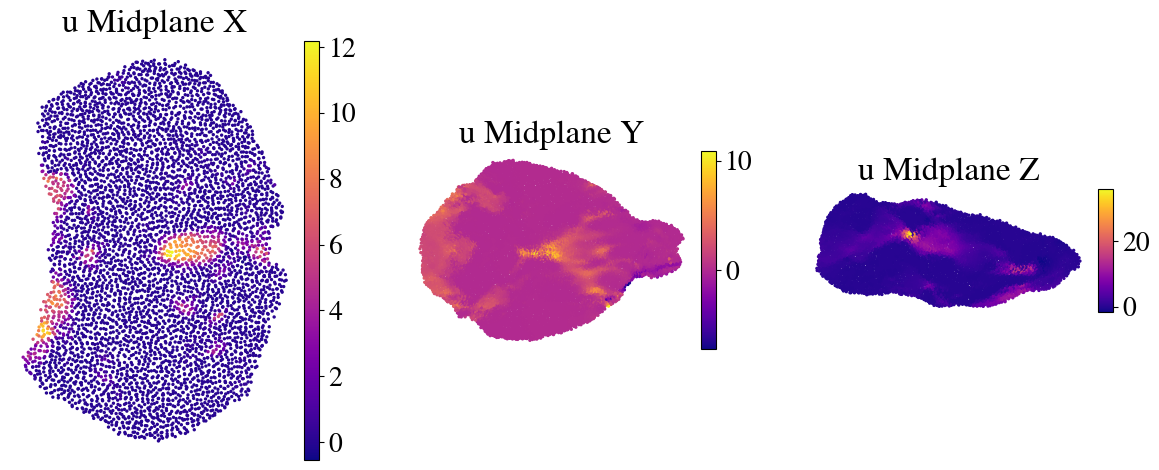

In [26]:
X_plot = X_test_crop

t,x, y, z, u = X_plot[:,0], X_plot[:,1], X_plot[:,2], X_plot[:,3], X_plot[:,4]
t2,x2, y2, z2, c2 = X_plot[:,0], X_plot[:,1], X_plot[:,2], X_plot[:,3], X_plot[:,4]

# Calculate midplane values
x_midplane = np.median(x)
y_midplane = np.median(y)
z_midplane = np.median(z)

tolerance = 0.5  # Adjust based on your dataset's spread

# Define filters for each midplane
x_midplane_filter = np.abs(x - x_midplane) <= tolerance
y_midplane_filter = np.abs(y - y_midplane) <= tolerance
z_midplane_filter = np.abs(z - z_midplane) <= tolerance

# Prepare for visualization

# Variables for plotting
variables = [u]  # Use the scalar field for coloring
variable_names = ['u']

# Visualization
for i, var in enumerate(variables):
    fig = plt.figure(figsize=(12, 8))  # Adjust size as needed

    for j in range(3):
        ax = fig.add_subplot(1, 3, j + 1)
        if j == 0:
            filter_mask = x_midplane_filter
            scatter_x, scatter_y = y[filter_mask], z[filter_mask]
            xlabel, ylabel = 'Y', 'Z'
        elif j == 1:
            filter_mask = y_midplane_filter
            scatter_x, scatter_y = x[filter_mask], z[filter_mask]
            xlabel, ylabel = 'X', 'Z'
        else:  # j == 2
            filter_mask = z_midplane_filter
            scatter_x, scatter_y = x[filter_mask], y[filter_mask]
            xlabel, ylabel = 'X', 'Y'

        # Use the scalar field for coloring
        scatter = ax.scatter(scatter_x, scatter_y, c=var[filter_mask], cmap=cmap, s=2)
        ax.set_title(f'{variable_names[i]} Midplane {["X", "Y", "Z"][j]}')
        #ax.set_xlabel(xlabel)
        #ax.set_ylabel(ylabel)
        ax.axis('equal')
        ax.axis('off')  # Change to 'off' if you prefer no axis

        # Adding a colorbar to each subplot
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(scatter, cax=cax)

plt.tight_layout()
plt.show()


### Load boundary information
 

In [27]:
df_bcs = pd.read_csv(outlet1_path)
X_out = df_bcs.to_numpy()
print(df_bcs.columns)
print(X_out.shape)
non_dim_fact_bcs=np.array(([[1/T_char,1/(1000*L_char),1/(1000*L_char),1/(1000*L_char),
                             1/(1000*L_char), 1/(1000*L_char),1/(1000*L_char),1/P_char
                             ,1/U_char,1/U_char,1/U_char]]))
print(non_dim_fact_bcs.shape)

Index(['X', 'Y', 'Z', 'nx @ t=0', 'ny @ t=0', 'nz @ t=0', 'p (Pa) @ t=0',
       'dl.u (m/s) @ t=0', 'dl.v (m/s) @ t=0', 'dl.w (m/s) @ t=0'],
      dtype='object')
(2786, 10)
(1, 11)


In [28]:
df_bcs = pd.read_csv(out_BCs_path)
X_out = df_bcs.to_numpy()
print(X_out.shape)
X_out=np.hstack((X_out[:,0:1],X_out[:,:6],X_out[:,6:]))
X_out=X_out*non_dim_fact_bcs
df_bcs = pd.read_csv(outlet1_path)
X_o1 = df_bcs.to_numpy()
X_outlets=np.hstack((X_o1[:,0:1],X_o1[:,:6],X_o1[:,6:]))
X_outlets=X_outlets*non_dim_fact_bcs
df_bcs = pd.read_csv(inlet1_path)
X_inlet = df_bcs.to_numpy()
X_inlet=np.hstack((X_inlet[:,0:1],X_inlet[:,:6],X_inlet[:,6:]))
X_inlet=X_inlet*non_dim_fact_bcs
X_in_out=np.vstack((X_inlet,X_outlets))

(448051, 10)


## Scale concentration and remove initial time steps


  0%|          | 0/85 [00:00<?, ?it/s]

100%|██████████| 85/85 [00:00<00:00, 425.89it/s]


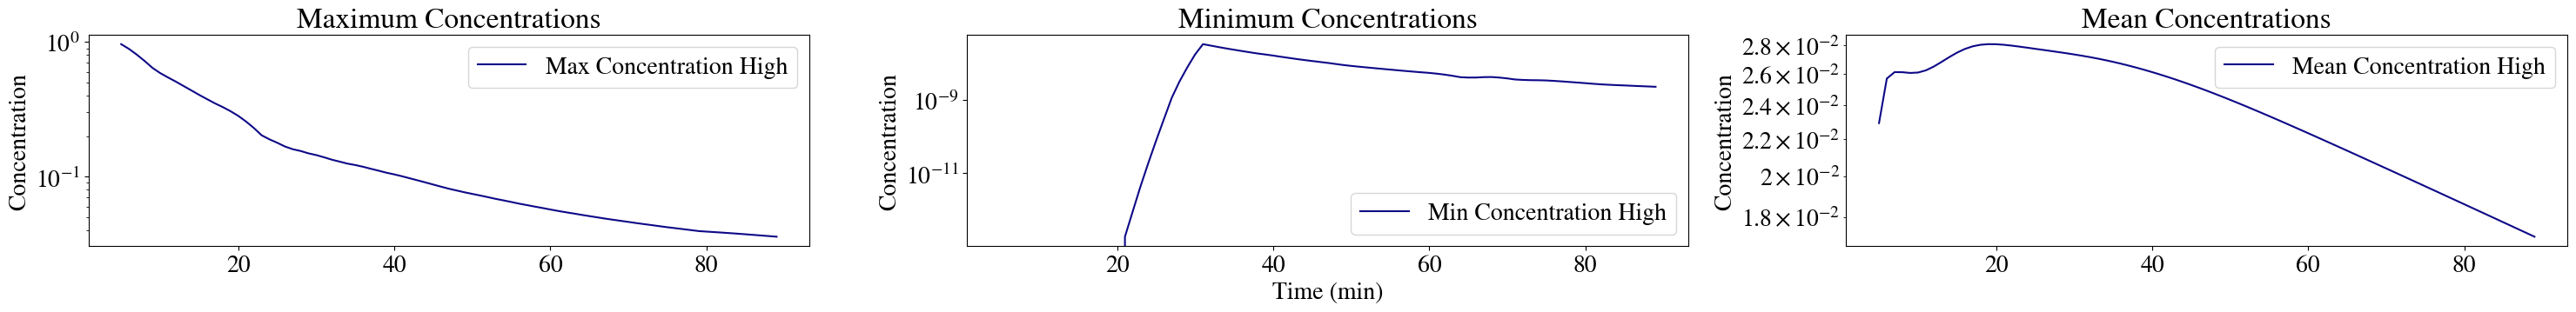

0.9652471709350805


100%|██████████| 85/85 [00:01<00:00, 60.55it/s]


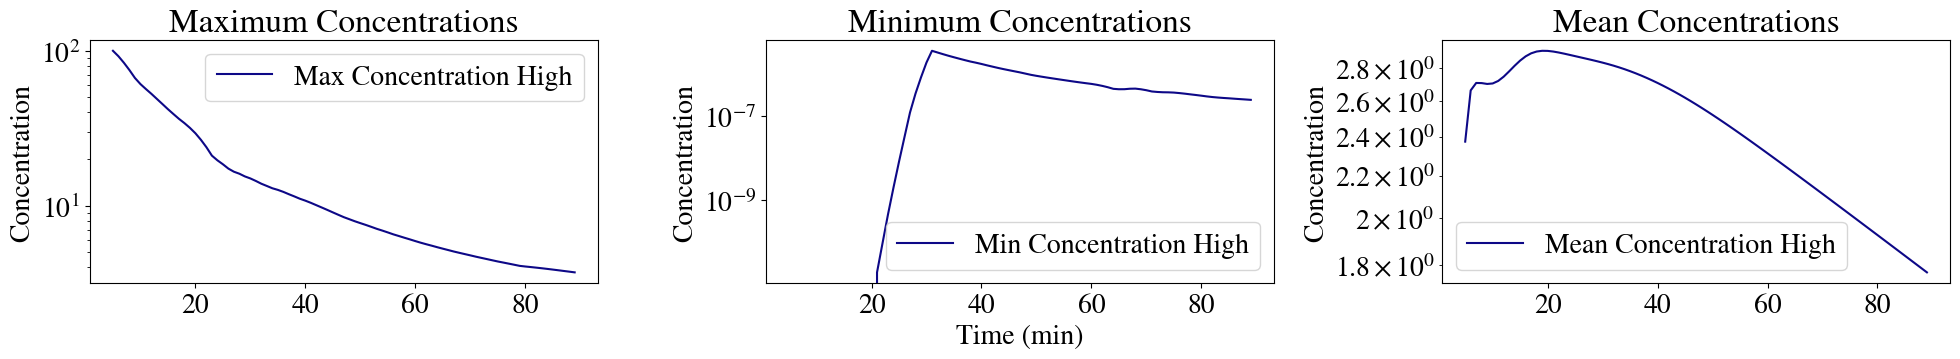

In [29]:
avoid_from=5
avoid_from_org=np.copy(avoid_from)
X_c_H=[]
X_res_H=[]
C_max_H=[]
C_min_H=[]
C_mean_H=[]

X_c_L=[]
X_res_L=[]
C_max_L=[]
C_min_L=[]
C_mean_L=[]

diff_time=[]
all_frames=[]
tol=0.05
for it in tqdm.tqdm(range(avoid_from,len(X_nnf))):
    all_frames.append(it)

    X_frame_H=X_nnf[it]

    time_H=X_frame_H[0,0]

    C_max_H.append(np.max(X_frame_H[:,4:5]))
    C_min_H.append(np.min(X_frame_H[:,4:5]))
    C_mean_H.append(np.mean(X_frame_H[:,4:5]))


# Creating the figure with 3 subplots
fig, axs = plt.subplots(1, 3, figsize=(30, 4))

# Plotting Max Concentrations for High and Low
axs[0].plot(all_frames, C_max_H, label='Max Concentration High')
axs[0].set_yscale('log')
axs[0].set_title('Maximum Concentrations')
axs[1].set_xlabel('Time (min)')
axs[0].set_ylabel('Concentration')
axs[0].legend()

# Plotting Min Concentrations for High and Low
axs[1].plot(all_frames, C_min_H, label='Min Concentration High')
axs[1].set_yscale('log')
axs[1].set_title('Minimum Concentrations')
axs[1].set_xlabel('Time (min)')
axs[1].set_ylabel('Concentration')
axs[1].legend()

# Plotting Mean Concentrations for High and Low
axs[2].plot(all_frames, C_mean_H, label='Mean Concentration High')
axs[2].set_yscale('log')
axs[2].set_title('Mean Concentrations')
axs[1].set_xlabel('Time (min)')
axs[2].set_ylabel('Concentration')
axs[2].legend()

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

min_H=np.min(C_min_H)
max_H=np.max(C_max_H)-min_H

max_all=max_H
print(max_all)
keep_c=max_H

X_c_H=[]
X_res_H=[]
C_max_H=[]
C_min_H=[]
C_mean_H=[]

X_c_L=[]
X_res_L=[]
C_max_L=[]
C_min_L=[]
C_mean_L=[]
X_nnf_bd=[]
all_frames=[]
for it in tqdm.tqdm(range(avoid_from,len(X_nnf))):
    all_frames.append(it)

    X_frame_H=X_nnf[it,:,:5]-min_H
    idx_keep0=np.argwhere(X_frame_H[:,4]<=keep_c).flatten()
    X_frame_H=X_frame_H[idx_keep0]*np.array([[1,1,1,1,100/keep_c]])

    C_max_H.append(np.max(X_frame_H[:,4:5]))
    C_min_H.append(np.min(X_frame_H[:,4:5]))
    C_mean_H.append(np.mean(X_frame_H[:,4:5]))

    idx_keep=np.argwhere(X_frame_H[:,4]>tol*np.mean(X_frame_H[:,4:5])).flatten()
    X_res_H.append(X_frame_H[idx_keep])
    X_c_H.append(X_frame_H)

    X_nnf_bd.append(X_frame_H)




# Creating the figure with 3 subplots
fig, axs = plt.subplots(1, 3, figsize=(20, 4))

# Plotting Max Concentrations for High and Low
axs[0].plot(all_frames, C_max_H, label='Max Concentration High')
axs[0].set_yscale('log')
axs[0].set_title('Maximum Concentrations')
axs[1].set_xlabel('Time (min)')
axs[0].set_ylabel('Concentration')
axs[0].legend()

# Plotting Min Concentrations for High and Low
axs[1].plot(all_frames, C_min_H, label='Min Concentration High')
axs[1].set_yscale('log')
axs[1].set_title('Minimum Concentrations')
axs[1].set_xlabel('Time (min)')
axs[1].set_ylabel('Concentration')
axs[1].legend()

# Plotting Mean Concentrations for High and Low
axs[2].plot(all_frames, C_mean_H, label='Mean Concentration High')
axs[2].set_yscale('log')
axs[2].set_title('Mean Concentrations')
axs[1].set_xlabel('Time (min)')
axs[2].set_ylabel('Concentration')
axs[2].legend()

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()



### Select Training and Testing Data

### Time sampling

In [30]:
frames=X_c_H
avoid_from=0
if train_ratio<=0.5:
    skip_frames = int(1 / train_ratio)
    idx_all_frames = np.arange(avoid_from, len(frames))
    idx_Train = np.arange(avoid_from+1, len(frames) - 1, skip_frames)
    idx_Train = np.append([avoid_from], idx_Train) 
    idx_Train = np.append(idx_Train, [len(frames) - 1]) 
    idx_Test = np.setdiff1d(idx_all_frames, idx_Train)
    print(f'Skipping:{skip_frames}')
    print(f'Training on frames:{idx_Train}')
    print(f'Testing on frames:{idx_Test}')
    print(f'Training on {len(idx_Train)/len(frames)}')
else:
    idx_all_frames =np.arange(avoid_from,len(frames))
    idx_Train=np.random.choice(len(frames)-avoid_from,int((len(frames)-avoid_from)*train_ratio),replace=False)+avoid_from
    idx_Train = np.append([avoid_from], idx_Train) 
    idx_Train = np.append(idx_Train, [len(frames) - 1])  
    idx_Train = np.unique(idx_Train)
    idx_Test =np.setdiff1d(idx_all_frames,idx_Train)
    print(f'There are not enough frames to skip')
    print(f'Training on frames:{np.sort(idx_Train)}')
    print(f'Testing on frames:{idx_Test}')
    print(f'Training on {len(idx_Train)/len(frames)}')
X_train=np.zeros((1,5))
for idx in tqdm.tqdm(idx_Train):
    X_train=np.vstack((X_train,X_c_H[idx]))
X_train_H=np.copy(X_train[1:])
X_test=np.zeros((1,5))
for idx in tqdm.tqdm(idx_Test):
    X_test=np.vstack((X_test,X_c_H[idx]))
X_test_H=np.copy(X_test[1:])

Skipping:2
Training on frames:[ 0  1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45
 47 49 51 53 55 57 59 61 63 65 67 69 71 73 75 77 79 81 83 84]
Testing on frames:[ 2  4  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40 42 44 46 48
 50 52 54 56 58 60 62 64 66 68 70 72 74 76 78 80 82]
Training on 0.5176470588235295


100%|██████████| 41/41 [00:01<00:00, 33.87it/s] 


### Spatial sampling

In [31]:
X_res_H=np.vstack(X_res_H)

X_train_H=np.vstack(X_train_H)
X_test_H=np.vstack(X_test_H)

num_points=150000
if len(X_test_H)<num_points:
    X_GT_H=np.copy(X_test_H)
else:   
    idx_Gt=np.random.choice(len(X_test_H),num_points,replace=False)
    X_GT_H=X_test_H[idx_Gt]

# Printing the shapes of the datasets for verification
print(f"Training set shape high: {X_train_H.shape}")
print(f"Test set shape high: {X_train_H.shape}")
print(f"Test Eval set shape high: {X_GT_H.shape}")
print(f"Residual set shape high: {X_res_H.shape}")

Training set shape high: (6547376, 5)
Test set shape high: (6547376, 5)
Test Eval set shape high: (150000, 5)
Residual set shape high: (9693581, 5)


In [32]:
idx_res=np.random.choice(len(X_res_H),len(X_res_H),replace=False)
idx_data=np.random.choice(len(X_train_H),len(X_train_H),replace=False)
X_res=X_res_H[idx_res]
X_train=X_train_H[idx_data]
X_train=np.hstack([X_train_H,X_train_H[:,0:1]*0+1])
X_GT=X_GT_H

#### Split data for AD equation

In [33]:
def get_data_between(X_res_H,t_0):
    t_f=t_0+delta_t_2
    idx_0=np.argwhere(X_res_H[:,0]>t_0).flatten()
    idx_f=np.argwhere(X_res_H[:,0]<t_f).flatten()
    idx_keep=np.intersect1d(idx_0,idx_f)
    return X_res_H[idx_keep]
all_times_res=np.sort(np.unique(X_res[:,0]))
t_max=np.max(all_times_res)
t_min=np.min(all_times_res)
n_steps=3
delta_t=(t_max-t_min)/(n_steps)
delta_t_2=0.8*delta_t
print(delta_t,delta_t_2)

X_res_1=get_data_between(X_res_H,t_min)
X_res_2=get_data_between(X_res_H,t_min+delta_t)
X_res_3=get_data_between(X_res_H,t_min+2*delta_t)

8.235294117647058 6.588235294117647


## Data Analytics

In [34]:
# %%
print(f'Bounds for Data Train with {X_train.shape} points:')
print(np.min(X_train,axis=0))
print(np.max(X_train,axis=0))
print(f'Bounds for front tracking Data with {X_init_clean.shape} points:')
print(np.min(X_init_clean,axis=0))
print(np.max(X_init_clean,axis=0))
print(f'Bounds for uvw Test with {X_test2.shape} points:')
print(np.min(X_test2,axis=0))
print(np.max(X_test2,axis=0))
print(f'Bounds for Data Eval with {X_GT.shape} points:')
print(np.min(X_GT,axis=0))
print(np.max(X_GT,axis=0))  
print(f'Bounds for Residual_1 Data with {X_res_1.shape} points:')
print(np.min(X_res_1,axis=0))
print(np.max(X_res_1,axis=0))
print(f'Bounds for Residual_2 Data with {X_res_2.shape} points:')
print(np.min(X_res_2,axis=0))
print(np.max(X_res_2,axis=0))
print(f'Bounds for Residual_3 Data with {X_res_3.shape} points:')
print(np.min(X_res_3,axis=0))
print(np.max(X_res_3,axis=0))
# %%
dataset = {
    'Data': X_train,
    'Test': X_test2 ,
    'Test_crop':X_test_crop,
    'Res_1': X_res_1,
    'Res_2': X_res_2,
    'Res_3': X_res_3,
    'GT': X_GT
}
lam = {
    'P': 1e-10,
    'Mass': 1e-16,
    'Data': 100,
}
neq = {
    'Data': 2,
    'Test': 1,
    'Test_crop': 1,
    'Res_1': 2,
    'Res_2': 2,
    'Res_3': 2,
    'GT': 1,
}


Bounds for Data Train with (6547376, 6) points:
[ 1.47058824  6.93294118 12.14470588  5.15117647  0.          1.        ]
[ 26.17647059  48.66176471  32.93529412  33.54117647 100.
   1.        ]
Bounds for front tracking Data with (400097, 5) points:
[ 9.55882353e-03  5.73529412e+00  1.07352941e+01  3.97058824e+00
 -3.61518367e-11]
[ 0.08308824 49.85294118 33.97058824 34.55882353 38.29102884]
Bounds for uvw Test with (148804, 8) points:
[ 1.15549020e-02  6.93294118e+00  1.21447059e+01  5.15117647e+00
 -3.91596000e+01 -1.68948000e+01 -7.13940000e+01  1.05239064e+01]
[8.11029412e-02 4.86617647e+01 3.29352941e+01 3.35411765e+01
 3.59868000e+01 8.58540000e+01 7.24980000e+00 3.82629487e+01]
Bounds for Data Eval with (150000, 5) points:
[ 2.05882353  6.93294118 12.17529412  5.15117647  0.        ]
[25.58823529 48.66176471 32.88823529 33.53529412 80.18696202]
Bounds for Residual_1 Data with (1228722, 5) points:
[ 1.76470588  6.93294118 12.14470588  5.32147059  0.1331256 ]
[ 7.94117647 46.2235

# RBA_Weights

In [35]:
lenghts=[]
for key in dataset.keys():
    lenghts.append(len(dataset[key]))
    print(f'Lenght of {key} dataset: {len(dataset[key])}')
N_train=int(np.max(lenghts))
if batch_size<0:
    batch_size=N_train
All_its=int(np.ceil(N_train/batch_size))
BATCH_SIZES = {}


for key in dataset.keys():
    if not(key == 'GT' or key == 'Test'):
        BATCH_SIZES[key] = int(np.ceil(len(dataset[key]) / All_its))
        if args.Equal_Batch:
            BATCH_SIZES[key]=batch_size
        print(f'Batch size for {key} dataset: {BATCH_SIZES[key]}')
    

lambdas={}
for key in dataset.keys():
    np.random.seed(seed_np)
    if not(key == 'GT' or key == 'Test'):
        lambdas[key] = np.random.uniform(0, 1, size=(len(dataset[key]), neq[key]))
        if init_zero:
            lambdas[key]= lambdas[key]*0+max_lambda/5
        print(f'Lambda shape for {key} dataset: {lambdas[key].shape}')
         



Lenght of Data dataset: 6547376
Lenght of Test dataset: 148804
Lenght of Test_crop dataset: 125332
Lenght of Res_1 dataset: 1228722
Lenght of Res_2 dataset: 2923448
Lenght of Res_3 dataset: 3161745
Lenght of GT dataset: 150000
Batch size for Data dataset: 10000
Batch size for Test_crop dataset: 10000
Batch size for Res_1 dataset: 10000
Batch size for Res_2 dataset: 10000
Batch size for Res_3 dataset: 10000


Lambda shape for Data dataset: (6547376, 2)
Lambda shape for Test_crop dataset: (125332, 1)
Lambda shape for Res_1 dataset: (1228722, 2)
Lambda shape for Res_2 dataset: (2923448, 2)
Lambda shape for Res_3 dataset: (3161745, 2)


# Loss Functions

In [36]:

def Advec_Diff_Eq_full(params):
    # Neural Network
    fn={
        'P' :lambda x: pinn_fn(params['P'], jnp.array([0.0,x[1],x[2],x[3]]), M1, M2,activation_fn,norm_fn),
        'c' :lambda x: pinn_fn(params['c'], x, M1, M2,activation_fn,norm_fn),
        'k' :lambda x: pinn_fn(params['k'], jnp.array([0.0,x[1],x[2],x[3]]), M1_all['k'], M2_all['k'],activation_fn,norm_fn),
        'D' :lambda x: pinn_fn(params['D'], jnp.array([0.0,x[1],x[2],x[3]]), M1_all['D'], M2_all['D'],activation_fn,norm_fn),
    }
    #Pretrained Models
    log_k= (
                 lambda x:-(lb_all['k']+ub_all['k']*jax.nn.sigmoid(fn['k'](x)[0])))
    k= (
                 lambda x: (jnp.exp(log_k(x)+off_set['k']))
                 )
    log_D= (
                 lambda x:-(lb_all['D']+ub_all['D']*jax.nn.sigmoid(fn['D'](x)[0]))
                 )
    D= (
                 lambda x: jnp.exp(log_D(x)+off_set['D'])
                 )

    #New Models
    p,c= (
                 lambda x: fn['P'](x)[0], 
                 lambda x: fn['c'](x)[0],
                 )
   # derivatives
    def derivative_fn(f, x, idx):
        """Computes df/dx[idx] using forward mode AD."""
        perturbation = jnp.zeros_like(x)
        perturbation = perturbation.at[idx].set(1.0)
        primals, tangents = jvp(f, (x,), (perturbation,))
        return tangents

    p_x = lambda x: derivative_fn(p, x, 1)
    p_y = lambda x: derivative_fn(p, x, 2)
    p_z = lambda x: derivative_fn(p, x, 3)

    u = lambda x:-p_scale*k(x)*p_x(x)
    v = lambda x:-p_scale*k(x)*p_y(x)
    w = lambda x:-p_scale*k(x)*p_z(x)

    u_x = lambda x: derivative_fn(u, x, 1)
    v_y = lambda x: derivative_fn(v, x, 2)
    w_z = lambda x: derivative_fn(w, x, 3)

    c_t = lambda x: derivative_fn(c, x, 0)
    c_x = lambda x: derivative_fn(c, x, 1)
    c_y = lambda x: derivative_fn(c, x, 2)
    c_z = lambda x: derivative_fn(c, x, 3)
    c_xx = lambda x: derivative_fn(c_x, x, 1)
    c_yy = lambda x: derivative_fn(c_y, x, 2)
    c_zz = lambda x: derivative_fn(c_z, x, 3)

    D_x = lambda x: derivative_fn(D, x, 1)
    D_y = lambda x: derivative_fn(D, x, 2)
    D_z = lambda x: derivative_fn(D, x, 3)

     # equations
    eq0= (
        lambda x:c_t(x) 
        + (u(x) * c_x(x) + v(x) * c_y(x) + w(x) * c_z(x)) 
        - (1/Pe)*(c_xx(x) + c_yy(x) + c_zz(x)))

    eq6 = lambda x: (u_x(x) + v_y(x) + w_z(x))

    
    return eq0, eq6


In [37]:

def gradients_c(params):
    # Neural Network
    fn={
        'P' :lambda x: pinn_fn(params['P'], jnp.array([0.0,x[1],x[2],x[3]]), M1, M2,activation_fn,norm_fn),
        'c' :lambda x: pinn_fn(params['c'], x, M1, M2,activation_fn,norm_fn),
        'k' :lambda x: pinn_fn(params['k'], jnp.array([0.0,x[1],x[2],x[3]]), M1_all['k'], M2_all['k'],activation_fn,norm_fn),
        'D' :lambda x: pinn_fn(params['D'], jnp.array([0.0,x[1],x[2],x[3]]), M1_all['D'], M2_all['D'],activation_fn,norm_fn),
    }

    #New Models
    c= lambda x: fn['c'](x)[0]
   # derivatives
    def derivative_fn(f, x, idx):
        """Computes df/dx[idx] using forward mode AD."""
        perturbation = jnp.zeros_like(x)
        perturbation = perturbation.at[idx].set(1.0)
        primals, tangents = jvp(f, (x,), (perturbation,))
        return tangents

    c_t = lambda x: derivative_fn(c, x, 0)
    c_x = lambda x: derivative_fn(c, x, 1)
    c_y = lambda x: derivative_fn(c, x, 2)
    c_z = lambda x: derivative_fn(c, x, 3)
    c_xx = lambda x: derivative_fn(c_x, x, 1)
    c_yy = lambda x: derivative_fn(c_y, x, 2)
    c_zz = lambda x: derivative_fn(c_z, x, 3)

  
    return c_x, c_y,c_z,c_xx,c_yy,c_zz


In [38]:
sigma_0=0.01
k_loss=jnp.log(sigma_0**2)/2
def NLL(r,sigma,weight=1):# r is the residual r=(y-mu), sigma is the sandard deviation
    nnl=jnp.log(sigma**2)/2+(r)**2/(2*sigma**2)-k_loss
    return jnp.mean(weight*nnl)

In [39]:
def u_PINN(params):
    # Neural Network
    fn={
        'P' :lambda x: pinn_fn(params['P'], jnp.array([0.0,x[1],x[2],x[3]]), M1, M2,activation_fn,norm_fn),
        'c' :lambda x: pinn_fn(params['c'], x, M1, M2,activation_fn,norm_fn),
        'c_std' :lambda x: pinn_fn(params['c_std'], x, M1, M2,activation_fn,norm_fn),
        'k' :lambda x: pinn_fn(params['k'], jnp.array([0.0,x[1],x[2],x[3]]), M1_all['k'], M2_all['k'],activation_fn,norm_fn),
        'D' :lambda x: pinn_fn(params['D'], jnp.array([0.0,x[1],x[2],x[3]]), M1_all['D'], M2_all['D'],activation_fn,norm_fn),
    }
    #Pretrained Models
    log_k= (
                 lambda x:-(lb_all['k']+ub_all['k']*jax.nn.sigmoid(fn['k'](x)[0])))
    k= (
                 lambda x: (jnp.exp(log_k(x)+off_set['k']))
                 )
    log_D= (
                 lambda x:-(lb_all['D']+ub_all['D']*jax.nn.sigmoid(fn['D'](x)[0]))
                 )
    D= (
                 lambda x: jnp.exp(log_D(x)+off_set['D'])
                 )
    #New Models
    p,c,c_std= (
                 lambda x: fn['P'](x)[0], 
                 lambda x: fn['c'](x)[0],
                 lambda x: 10*jax.nn.sigmoid(fn['c_std'](x)[0])+sigma_0,
                 )
   # derivatives
    def derivative_fn(f, x, idx):
        """Computes df/dx[idx] using forward mode AD."""
        perturbation = jnp.zeros_like(x)
        perturbation = perturbation.at[idx].set(1.0)
        primals, tangents = jvp(f, (x,), (perturbation,))
        return tangents

    p_x = lambda x: derivative_fn(p, x, 1)
    p_y = lambda x: derivative_fn(p, x, 2)
    p_z = lambda x: derivative_fn(p, x, 3)

    u = lambda x:-p_scale*k(x)*p_x(x)
    v = lambda x:-p_scale*k(x)*p_y(x)
    w = lambda x:-p_scale*k(x)*p_z(x)
    return u,v,w,p,c,D,k,c_std

u_model=u_PINN


## Training

In [40]:
def compute_prediction(X, funcs):
    result = jnp.zeros((X.shape[0], len(funcs)))
    for i, fn in enumerate(funcs):
        result = result.at[:, i].set(vmap(fn, (0))(X[:, :layers_ref[0]]).flatten())
    return result

In [41]:
key='Permeability'
Dataset2={}
Dataset2['Permeability']=X_permeability
u_fx,v_fx,w_fx,p_fx,c_fx,D_fx,k_fx,c_std_fx  = u_model(params)
# Further computations for errors if any
K_pred  = vmap(k_fx, (0))(Dataset2[key][:,0:layers_ref[0]])[:,None]*k_char
K_true=X_permeability[:,5:6]*k_char
print(K_pred.min(),K_pred.max())

print('Error',relative_error2(K_pred,K_true))

9.730953e-17 1.0064552e-12
Error 0.8941946936050097


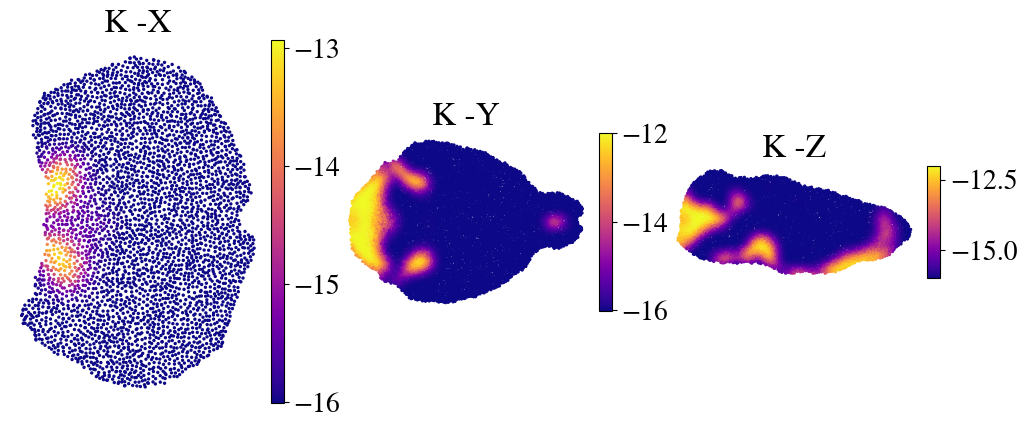

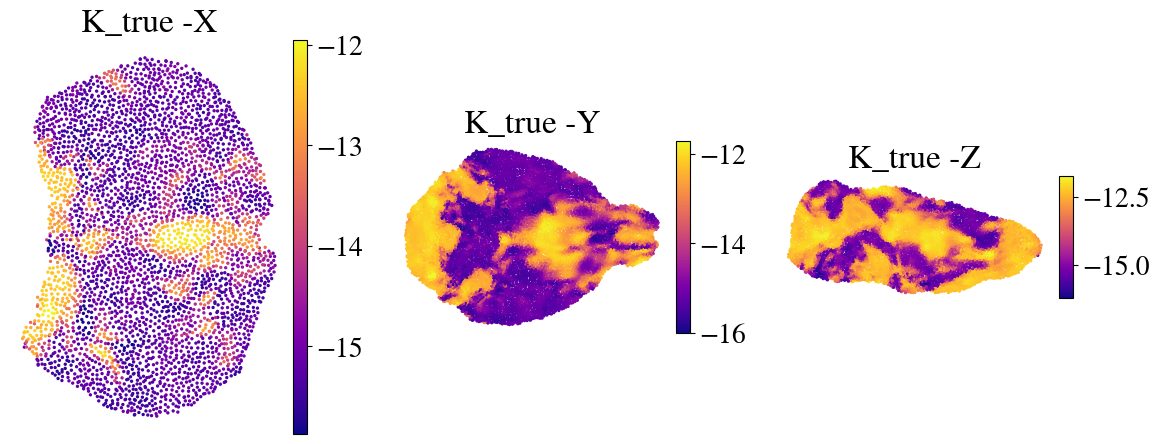

In [42]:
t,x, y, z= Dataset2[key][:,0], Dataset2[key][:,1], Dataset2[key][:,2], Dataset2[key][:,3]
# Calculate midplane values
x_midplane = np.median(x)
y_midplane = np.median(y)
z_midplane = np.median(z)

tolerance = 0.3  # Adjust based on your dataset's spread

# Define filters for each midplane
x_midplane_filter = np.abs(x - x_midplane) <= tolerance
y_midplane_filter = np.abs(y - y_midplane) <= tolerance
z_midplane_filter = np.abs(z - z_midplane) <= tolerance

# Prepare for visualization

# Variables for plotting
variables = [np.log10(K_pred),np.log10(K_true)]  # Use the scalar field for coloring
variable_names = ['K','K_true']

# Visualization
for i, var in enumerate(variables):
    fig = plt.figure(figsize=(12, 8))  # Adjust size as needed

    for j in range(3):
        ax = fig.add_subplot(1, 3, j + 1)
        if j == 0:
            filter_mask = x_midplane_filter
            scatter_x, scatter_y = y[filter_mask], z[filter_mask]
            xlabel, ylabel = 'Y', 'Z'
        elif j == 1:
            filter_mask = y_midplane_filter
            scatter_x, scatter_y = x[filter_mask], z[filter_mask]
            xlabel, ylabel = 'X', 'Z'
        else:  # j == 2
            filter_mask = z_midplane_filter
            scatter_x, scatter_y = x[filter_mask], y[filter_mask]
            xlabel, ylabel = 'X', 'Y' 

        # Use the scalar field for coloring
        scatter = ax.scatter(scatter_x, scatter_y, c=var[filter_mask], cmap=cmap, s=2)
        ax.set_title(f'{variable_names[i]} -{["X", "Y", "Z"][j]}')
        #ax.set_xlabel(xlabel)
        #ax.set_ylabel(ylabel)
        ax.axis('equal')
        ax.axis('off')  # Change to 'off' if you prefer no axis

        # Adding a colorbar to each subplot
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(scatter, cax=cax)

plt.tight_layout()
plt.savefig(images_path+'Final_results.png')
plt.show()


In [43]:
@jit
def update_stage_0(params, lambdas,lam,Pe, opt_state, dataset: Dict[str, np.ndarray], batch_indices: Dict[str, np.ndarray]):
    # Compute the predictions based on the given functions.
    def compute_prediction(X, funcs):
        result = jnp.zeros((X.shape[0], len(funcs)))
        for i, fn in enumerate(funcs):
            result = result.at[:, i].set(vmap(fn, (0))(X[:, :layers_ref[0]]).flatten())
        return result
    def get_residuals_and_multipliers(key, dataset, functions, lambdas, target, it_details=None):
        batch_indices,gamma,lr_lambdas_0,use_RBA=it_details
        pred = compute_prediction(dataset[key], functions)
        residuals = jnp.abs(pred - target)
        lam_key = (gamma) * lambdas[key][batch_indices[key]] + lr_lambdas_0 * residuals / (jnp.max(residuals, axis=0) + 10**(-8))
        lambdas[key] = lambdas[key].at[batch_indices[key]].set(lam_key)
        lam_key = lam_key * use_RBA + 0.1
        return residuals,lam_key,lambdas
    it_details=(batch_indices,gamma,lr_lambdas_0,use_RBA)
    def loss_fn(params,lambdas):
        # eqn error
        eq0, eq6= Advec_Diff_Eq_full(params)
        u_fx,v_fx,w_fx,p_fx,c_fx,D_fx,k_fx,c_std_fx  = u_model(params)
        # Initialize dictionaries
        residuals={}
        multipliers={}
        # Equations
        residuals['Res_1'],multipliers['Res_1'],lambdas = get_residuals_and_multipliers('Res_1', dataset, #Dataset to compute predictions
                                                             [eq0, eq6 ], #Functions to evaluate
                                                             lambdas,  # local multipliers(NOTICE IT IS LAMBDA_0)
                                                             0.0,
                                                             it_details) 
        residuals['Res_2'],multipliers['Res_2'],lambdas = get_residuals_and_multipliers('Res_2', dataset, #Dataset to compute predictions
                                                             [eq0, eq6 ], #Functions to evaluate
                                                             lambdas,  # local multipliers(NOTICE IT IS LAMBDA_0)
                                                             0.0,
                                                             it_details) 
        residuals['Res_3'],multipliers['Res_3'],lambdas = get_residuals_and_multipliers('Res_3', dataset, #Dataset to compute predictions
                                                             [eq0, eq6 ], #Functions to evaluate
                                                             lambdas,  # local multipliers(NOTICE IT IS LAMBDA_0)
                                                             0.0,
                                                             it_details) 
        residuals['Data'],multipliers['Data'],lambdas  = get_residuals_and_multipliers('Data', dataset, #Dataset to compute predictions
                                                             [c_fx,c_std_fx], #Functions to evaluate
                                                             lambdas,  # local multiplieers
                                                             dataset['Data'][:,4:6],
                                                             it_details)
        
        loss_vals = {
            'AD': lam['P']*(Error_fn(residuals['Res_1'][:, 0:1], 0.0, weight=multipliers['Res_1'][:, 0:1])
                           +Error_fn(residuals['Res_2'][:, 0:1], 0.0, weight=multipliers['Res_2'][:, 0:1])
                           +Error_fn(residuals['Res_3'][:, 0:1], 0.0, weight=multipliers['Res_3'][:, 0:1])),
            'Mass':use_mass*lam['Mass']*(Error_fn(residuals['Res_1'][:, 1:2], 0.0, weight=multipliers['Res_1'][:, 1:2])
                                        +Error_fn(residuals['Res_2'][:, 1:2], 0.0, weight=multipliers['Res_2'][:, 1:2])
                                        +Error_fn(residuals['Res_3'][:, 1:2], 0.0, weight=multipliers['Res_3'][:, 1:2])),
            'c' :  lam['Data']*Error_fn(residuals['Data'][:, 0:1], 0.0, weight=multipliers['Data'][:, 0:1]),
            'c_std' :  lam['Data']*Error_fn(residuals['Data'][:, 1:2], 0.0, weight=multipliers['Data'][:, 1:2]),

        }
        Error_vals = {
            'AD':  (jnp.mean(residuals['Res_1'][:, 0:1])
                   +jnp.mean(residuals['Res_2'][:, 0:1])
                   +jnp.mean(residuals['Res_3'][:, 0:1])),
            'Mass':(jnp.mean(residuals['Res_1'][:, 1:2])
                   +jnp.mean(residuals['Res_2'][:, 1:2])
                   +jnp.mean(residuals['Res_3'][:, 1:2])),
            'c' :  jnp.mean(residuals['Data'][:, 0:1]),
        }

        # Total Loss
        total_loss = sum(loss_vals.values())

        return total_loss, (Error_vals, lambdas)

    # Compute gradients of the loss function with respect to parameters.
    grad_fn = value_and_grad(loss_fn, has_aux=True)
    (_, loss_dict_and_lambdas), grads = grad_fn(params,lambdas)
    losses_dict = loss_dict_and_lambdas[0]
    updated_lambdas = loss_dict_and_lambdas[1]

    # Update model parameters based on the calculated gradients.
    updates={}
    updates['P'], opt_state['P'] = optimizer['P'].update(grads['P'], opt_state['P'], params['P'])
    params['P'] = optax.apply_updates(params['P'], updates['P'])
    updates['c'], opt_state['c'] = optimizer['c'].update(grads['c'], opt_state['c'], params['c'])
    params['c'] = optax.apply_updates(params['c'], updates['c'])
    updates['c_std'], opt_state['c_std'] = optimizer['c_std'].update(grads['c_std'], opt_state['c_std'], params['c_std'])
    params['c_std'] = optax.apply_updates(params['c_std'], updates['c_std'])

    return params, updated_lambdas, opt_state, losses_dict


In [44]:
@jit
def update_stage_1(params, lambdas,lam,Pe, opt_state, dataset: Dict[str, np.ndarray], batch_indices: Dict[str, np.ndarray]):
    # Compute the predictions based on the given functions.
    def compute_prediction(X, funcs):
        result = jnp.zeros((X.shape[0], len(funcs)))
        for i, fn in enumerate(funcs):
            result = result.at[:, i].set(vmap(fn, (0))(X[:, :layers_ref[0]]).flatten())
        return result
    def get_residuals_and_multipliers(key, dataset, functions, lambdas, target, it_details=None):
        batch_indices,gamma,lr_lambdas_0,use_RBA=it_details
        pred = compute_prediction(dataset[key], functions)
        residuals = jnp.abs(pred - target)
        lam_key = (gamma) * lambdas[key][batch_indices[key]] + lr_lambdas_0 * residuals / (jnp.max(residuals, axis=0) + 10**(-8))
        lambdas[key] = lambdas[key].at[batch_indices[key]].set(lam_key)
        lam_key = lam_key * use_RBA + 0.1
        return residuals,lam_key,lambdas
    it_details=(batch_indices,gamma,lr_lambdas_0,use_RBA)
    def loss_fn(params,lambdas):
        # eqn error
        eq0, eq6= Advec_Diff_Eq_full(params)
        u_fx,v_fx,w_fx,p_fx,c_fx,D_fx,k_fx,c_std_fx  = u_model(params)
        # Initialize dictionaries
        residuals={}
        multipliers={}
        # Equations
        residuals['Res_1'],multipliers['Res_1'],lambdas = get_residuals_and_multipliers('Res_1', dataset, #Dataset to compute predictions
                                                             [eq0, eq6 ], #Functions to evaluate
                                                             lambdas,  # local multipliers(NOTICE IT IS LAMBDA_0)
                                                             0.0,
                                                             it_details) 
        residuals['Res_2'],multipliers['Res_2'],lambdas = get_residuals_and_multipliers('Res_2', dataset, #Dataset to compute predictions
                                                             [eq0, eq6 ], #Functions to evaluate
                                                             lambdas,  # local multipliers(NOTICE IT IS LAMBDA_0)
                                                             0.0,
                                                             it_details) 
        residuals['Res_3'],multipliers['Res_3'],lambdas = get_residuals_and_multipliers('Res_3', dataset, #Dataset to compute predictions
                                                             [eq0, eq6 ], #Functions to evaluate
                                                             lambdas,  # local multipliers(NOTICE IT IS LAMBDA_0)
                                                             0.0,
                                                             it_details) 
        residuals['Data'],multipliers['Data'],lambdas  = get_residuals_and_multipliers('Data', dataset, #Dataset to compute predictions
                                                             [c_fx,c_std_fx], #Functions to evaluate
                                                             lambdas,  # local multiplieers
                                                             dataset['Data'][:,4:6],
                                                             it_details)

        #Calculate Stds
        sigma_c=compute_prediction(dataset['Data'], [c_std_fx])

        
        loss_vals = {
            'AD': lam['P']*(Error_fn(residuals['Res_1'][:, 0:1], 0.0, weight=multipliers['Res_1'][:, 0:1])
                           +Error_fn(residuals['Res_2'][:, 0:1], 0.0, weight=multipliers['Res_2'][:, 0:1])
                           +Error_fn(residuals['Res_3'][:, 0:1], 0.0, weight=multipliers['Res_3'][:, 0:1])),
            'Mass':use_mass*lam['Mass']*(Error_fn(residuals['Res_1'][:, 1:2], 0.0, weight=multipliers['Res_1'][:, 1:2])
                                        +Error_fn(residuals['Res_2'][:, 1:2], 0.0, weight=multipliers['Res_2'][:, 1:2])
                                        +Error_fn(residuals['Res_3'][:, 1:2], 0.0, weight=multipliers['Res_3'][:, 1:2])),
            #'c' :  0.1*Error_fn(residuals['Data'][:, 0:1], 0.0, weight=multipliers['Data'][:, 0:1]),
            'c_std' :  lam['Data']*NLL(residuals['Data'][:, 0:1], sigma_c, weight=multipliers['Data'][:, 1:2]),
        }
        Error_vals = {
            'AD':  (jnp.mean(residuals['Res_1'][:, 0:1])
                   +jnp.mean(residuals['Res_2'][:, 0:1])
                   +jnp.mean(residuals['Res_3'][:, 0:1])),
            'Mass':(jnp.mean(residuals['Res_1'][:, 1:2])
                   +jnp.mean(residuals['Res_2'][:, 1:2])
                   +jnp.mean(residuals['Res_3'][:, 1:2])),
            'c' :  jnp.mean(residuals['Data'][:, 0:1]),
        }

        # Total Loss
        total_loss = sum(loss_vals.values())

        return total_loss, (Error_vals, lambdas)

    # Compute gradients of the loss function with respect to parameters.
    grad_fn = value_and_grad(loss_fn, has_aux=True)
    (_, loss_dict_and_lambdas), grads = grad_fn(params,lambdas)
    losses_dict = loss_dict_and_lambdas[0]
    updated_lambdas = loss_dict_and_lambdas[1]

    # Update model parameters based on the calculated gradients.
    updates={}
    updates['P'], opt_state['P'] = optimizer['P'].update(grads['P'], opt_state['P'], params['P'])
    params['P'] = optax.apply_updates(params['P'], updates['P'])
    updates['c'], opt_state['c'] = optimizer['c'].update(grads['c'], opt_state['c'], params['c'])
    params['c'] = optax.apply_updates(params['c'], updates['c'])
    updates['c_std'], opt_state['c_std'] = optimizer['c_std'].update(grads['c_std'], opt_state['c_std'], params['c_std'])
    params['c_std'] = optax.apply_updates(params['c_std'], updates['c_std'])
    

    return params, updated_lambdas, opt_state, losses_dict


In [45]:
# %%
if normalization.lower()=='fourier_time':
    M1=generate_random_matrix(embed_size//(2*input_dim),input_dim)
    M2=10
elif normalization.lower()=='fourier':
    M1=generate_random_matrix(embed_size//(2*input_dim),input_dim)
    M2=10
else:
    M1= Norm_metric1(dataset['Data'][:, :layers_ref[0]])
    M2= Norm_metric2(dataset['Data'][:, :layers_ref[0]])

# Training


In [46]:
save_params_dict(params,result_path,dataset_name,type='Test')
def compute_error_metrics(params,key='GT'):
    u_fx,v_fx,w_fx,p_fx,c_fx,D_fx,k_fx,c_std_fx  = u_model(params)
    # Further computations for errors if any
    c_pred  = vmap(c_fx, (0))(dataset[key][:,0:layers_ref[0]])[:,None]
    error_c = relative_error2(c_pred, dataset[key][:,4:5])
    return error_c

def compute_error_metrics_init(params,key='Test_crop'):
    u_fx,v_fx,w_fx,p_fx,c_fx,D_fx,k_fx,c_std_fx  = u_model(params)
    # Further computations for errors if any
    u_pred  = vmap(u_fx, (0))(dataset[key][:,0:layers_ref[0]])[:,None]
    v_pred  = vmap(v_fx, (0))(dataset[key][:,0:layers_ref[0]])[:,None]
    w_pred  = vmap(w_fx, (0))(dataset[key][:,0:layers_ref[0]])[:,None]
    p_pred  = vmap(p_fx, (0))(dataset[key][:,0:layers_ref[0]])[:,None]
    error_u = relative_error2(u_pred, dataset[key][:,4:5])
    error_v = relative_error2(v_pred, dataset[key][:,5:6])
    error_w = relative_error2(w_pred, dataset[key][:,6:7])
    error_p = relative_error2(p_pred-p_pred.mean(), dataset[key][:,6:7]-(dataset[key][:,6:7]).mean())

    return error_u, error_v, error_w,error_p

def compute_error_metrics_Inlet(params,key='Test'):
    u_fx,v_fx,w_fx,p_fx,c_fx,D_fx,k_fx,c_std_fx  = u_model(params)
    # Further computations for errors if any
    p_pred  = vmap(p_fx, (0))(dataset[key][:,0:layers_ref[0]])[:,None]
    error_p = relative_error2(p_pred, dataset[key][:,4:5])
    return error_p
def compute_error_permeability(params):
    key='Permeability'
    u_fx,v_fx,w_fx,p_fx,c_fx,D_fx,k_fx,c_std_fx  = u_model(params)
    # Further computations for errors if any
    K_pred  = vmap(k_fx, (0))(Dataset2[key][:,0:layers_ref[0]])[:,None]
    K_real  =Dataset2[key][:,5:6]
    K_SI=K_pred*k_char
    RL2_K = relative_error2(K_pred*k_char, K_real*k_char)
    return RL2_K

0it [00:00, ?it/s]

1it [00:00, 16.75it/s]


Params P have been saved!


1it [00:00,  9.54it/s]


Params c have been saved!


...

Params c_std have been saved!


1it [00:00, 53.64it/s]


Params k have been saved!


1it [00:00, 86.64it/s]

Params D have been saved!


In [47]:
initialization_step=5*num_gsteps//10. #Learn c
activate_physics=10*num_gsteps//10  #Learn c with std
alpha_list=[]
beta_list=[]
if Run_MODE=='Train':
    epoch_losses = []
    log_loss     = []
    log_epoch    = []
    log_lambdas  = []
    log_error_u  = []
    log_error_v  = []
    start_time = time.time()
    running_time = 0
    it = 0
    it_opt=0
    Pe=Pef
    update=update_stage_0
    while it <=num_gsteps:
        #Sample Points
        batch_indices=sample_points_PDF(it,BATCH_SIZES,dataset,lambdas,k=args.k_samp,c=args.c_samp)

        batch_data = {key: dataset[key][batch_indices[key]] for key in BATCH_SIZES}
        
        #Update parameters
        params,lambdas, opt_state, batch_losses = update(
        params,lambdas,lam,Pe, opt_state, batch_data,batch_indices)
        
        epoch_losses.append(batch_losses)
        # Print and Store
        if it % 1000 == 0 or it==initialization_step or it==activate_physics:
            it_opt=it_opt+1000
            lr = lr0 * decay_rate ** (it_opt / decay_step)
            if it==initialization_step:
                print(f"NEW STAGE: Learn c")
                print(f"Reinitializing lambdas:")
                lambdas={}
                for key in dataset.keys():
                    np.random.seed(seed_np)
                    if not(key == 'GT' or key == 'Test'):
                        lambdas[key] = np.random.uniform(0, 1, size=(len(dataset[key]), neq[key]))
                        if init_zero:
                            lambdas[key]= lambdas[key]*0+max_lambda/5
                        print(f'Lambda shape for {key} dataset: {lambdas[key].shape}')
                print(f"Reinitializing Optimizer:")
                Te=num_gsteps-it
                it_opt=0
                lr0=lr
                optimizer={}
                opt_state={}
                for key in layers.keys():
                    print(f'Initializing Optimizer for:{key}')
                    optimizer[key],decay_step= initialize_optimizer(lr0, decay_rate, lrf, decay_step, num_gsteps,optimizer_type=args.optimizer)
                    opt_state[key]=optimizer[key].init(params[key])
                update=update_stage_1
                print(f"Setting update function(Fix c):{update}")
                #Save parameters:
                save_params_dict(params,result_path,dataset_name,type='Stage_1',Use_ResNet=Use_ResNet)
                save_list(log_loss,result_path,f'{dataset_name}-Stage_1_loss')
            error_c= compute_error_metrics(params)
            error_u, error_v, error_w,error_p= compute_error_metrics_init(params)

            # Loss computation
            loss_avg_dict = {key: np.mean([loss[key] for loss in jax.device_get(epoch_losses)]) for key in epoch_losses[0].keys()}
            loss_avg_dict['RL2_u']=error_u
            loss_avg_dict['RL2_v']=error_v
            loss_avg_dict['RL2_w']=error_w
            loss_avg_dict['RL2_p']=error_p
            loss_avg_dict['RL2_c']=error_c
            loss_avg_dict['lr']=lr
            log_loss.append(loss_avg_dict)
            loss =sum(loss_avg_dict.values())
            epoch_losses = [] 

            # Lambda metrics
            lambda_res_metrics = {
                "Max": np.max(lambdas['Res_1']),
                "Min": np.min(lambdas['Res_1']),
                "Mean": np.mean(lambdas['Res_1'])
            }

            lambda_data_metrics = {
                "Max": np.max(lambdas['Data']),
                "Min": np.min(lambdas['Data']),
                "Mean": np.mean(lambdas['Data'])
            }
            # Compute learning rate (assuming you've defined lr0, decay_rate, decay_step earlier in the code)
            elapsed_time=time.time() - start_time
            running_time=running_time+elapsed_time
            

            print("-" * 100)
            print(args)
            print(f"It: {it:d}, Total Loss: {loss:.3e},lam Data:{lam['Data']:.3e},lam Physics:{lam['P']:.3e}")

            for key, value in loss_avg_dict.items():
                print(f"L1 {key.capitalize()}: {value:.3e}")

            print(f"Lambda PDE (Max): {lambda_res_metrics['Max']:.3e}, Lambda PDE (Min): {lambda_res_metrics['Min']:.3e}, Lambda PDE (Mean): {lambda_res_metrics['Mean']:.3e}")
            print(f"Lambda Data (Max): {lambda_data_metrics['Max']:.3e}, Lambda Data (Min): {lambda_data_metrics['Min']:.3e}, Lambda Data (Mean): {lambda_data_metrics['Mean']:.3e}")
            print(f'Iteration time: {elapsed_time:.2f}s, Total Time: {running_time/3600:.2f}h, Iteration/Total iterations: {it:.2f}/{num_gsteps:.2f}, Lr: {lr:.1e}')

            sys.stdout.flush()
            start_time = time.time()
            # Clean cache and run garbage collection
            update._clear_cache()
            gc.collect()
        if it % 50000 == 0 or it ==num_gsteps:
            save_list(log_loss,result_path,f'{dataset_name}-_loss')
            save_params_dict(params,result_path,dataset_name,type='Train',Use_ResNet=Use_ResNet)
        it += 1
for arg, value in vars(args).items():
    print(f'{arg}: {value}')

In [ ]:
if Run_MODE=='Train':
    save_list(log_loss,result_path,f'{dataset_name}-_Final_loss')
    save_list(log_error_u,result_path,f'{dataset_name}-_Final_error_u')
    save_list(log_error_v,result_path,f'{dataset_name}-_Final_error_v')
    save_params_dict(params,result_path,dataset_name,type='Final',Use_ResNet=Use_ResNet)

else:
    loaded_params = load_params_dict(result_path, dataset_name, layers, initialization,type='Final',Use_ResNet=Use_ResNet) 
    print('Parameters loaded from file')

    loss_path=result_path+f'{dataset_name}-_loss.npy'
    losses=np.load(loss_path,allow_pickle=True)
    log_loss=losses
    params=loaded_params
    print('Parameters Loaded from file')

100%|██████████| 1/1 [00:00<00:00, 31.61it/s]


Initializing:mlp parameters.


100%|██████████| 1/1 [00:00<00:00, 26.05it/s]


Initializing:mlp parameters.


100%|██████████| 1/1 [00:00<00:00, 21.03it/s]


Initializing:mlp parameters.


100%|██████████| 1/1 [00:00<00:00, 20.88it/s]


Initializing:mlp parameters.


100%|██████████| 1/1 [00:00<00:00, 44.66it/s]


Initializing:mlp parameters.
Parameters loaded from file
Parameters Loaded from file


In [ ]:
M1_all['c']=M1
M2_all['c']=M2

print(result_path)
print(dataset_name)
print(layers)
print(M1_all)
print(M2_all)

/users/jdtoscan/Documents/Papers/Instant_AIV//Results/Concentration_Pressure/Init_c_and_p1.0-Train:0.5_mass:1_RBA:1/General/
Init_c_and_p1.0-Train:0.5_mass:1_RBA:1
{'P': [20, 150, 150, 150, 150, 150, 1], 'c': [20, 200, 200, 200, 200, 200, 1], 'c_std': [20, 66, 66, 66, 66, 66, 1], 'k': [20, 50, 50, 50, 50, 1], 'D': [20, 150, 150, 150, 150, 150, 1]}
{'k': array([9.31372537e-03, 5.58823522e+00, 1.08823531e+01, 4.11764699e+00]), 'c': array([ 1.47058824,  6.93294118, 12.14470588,  5.15117647])}
{'k': array([ 0.08333333, 50.        , 34.11764818, 34.41176414]), 'c': array([26.17647059, 48.66176471, 32.93529412, 33.54117647])}


In [ ]:
file_details={
    'path':f'/Results/{Run_type}/{dataset_name}/General/',
    'name':dataset_name,
    'layers':layers,
    'lb_all':lb_all,
    'ub_all':ub_all,
    'off_set':off_set,
    'k_char0':k_char0,
    'offset_k':offset_k,
    'p_scale':p_scale,
    'M1':M1_all,
    'M2':M2_all
}
save_file_details=project_root+'Results/Initialization_Details.pkl'
with open(save_file_details, 'wb') as f:
    pickle.dump(file_details, f)
print(save_file_details)
print(file_details)

/users/jdtoscan/Documents/Papers/Instant_AIV/Results/Initialization_Details.pkl
{'path': '/Results/Concentration_Pressure/Init_c_and_p1.0-Train:0.5_mass:1_RBA:1/General/', 'name': 'Init_c_and_p1.0-Train:0.5_mass:1_RBA:1', 'layers': {'P': [20, 150, 150, 150, 150, 150, 1], 'c': [20, 200, 200, 200, 200, 200, 1], 'c_std': [20, 66, 66, 66, 66, 66, 1], 'k': [20, 50, 50, 50, 50, 1], 'D': [20, 150, 150, 150, 150, 150, 1]}, 'lb_all': {'k': np.float64(6.927673402377641)}, 'ub_all': {'k': np.float64(10.13137439170999)}, 'off_set': {'k': np.float64(12.302585092994047)}, 'k_char0': 1e-14, 'offset_k': 1.0, 'p_scale': 10, 'M1': {'k': array([9.31372537e-03, 5.58823522e+00, 1.08823531e+01, 4.11764699e+00]), 'c': array([ 1.47058824,  6.93294118, 12.14470588,  5.15117647])}, 'M2': {'k': array([ 0.08333333, 50.        , 34.11764818, 34.41176414]), 'c': array([26.17647059, 48.66176471, 32.93529412, 33.54117647])}}


## Losses and Errors

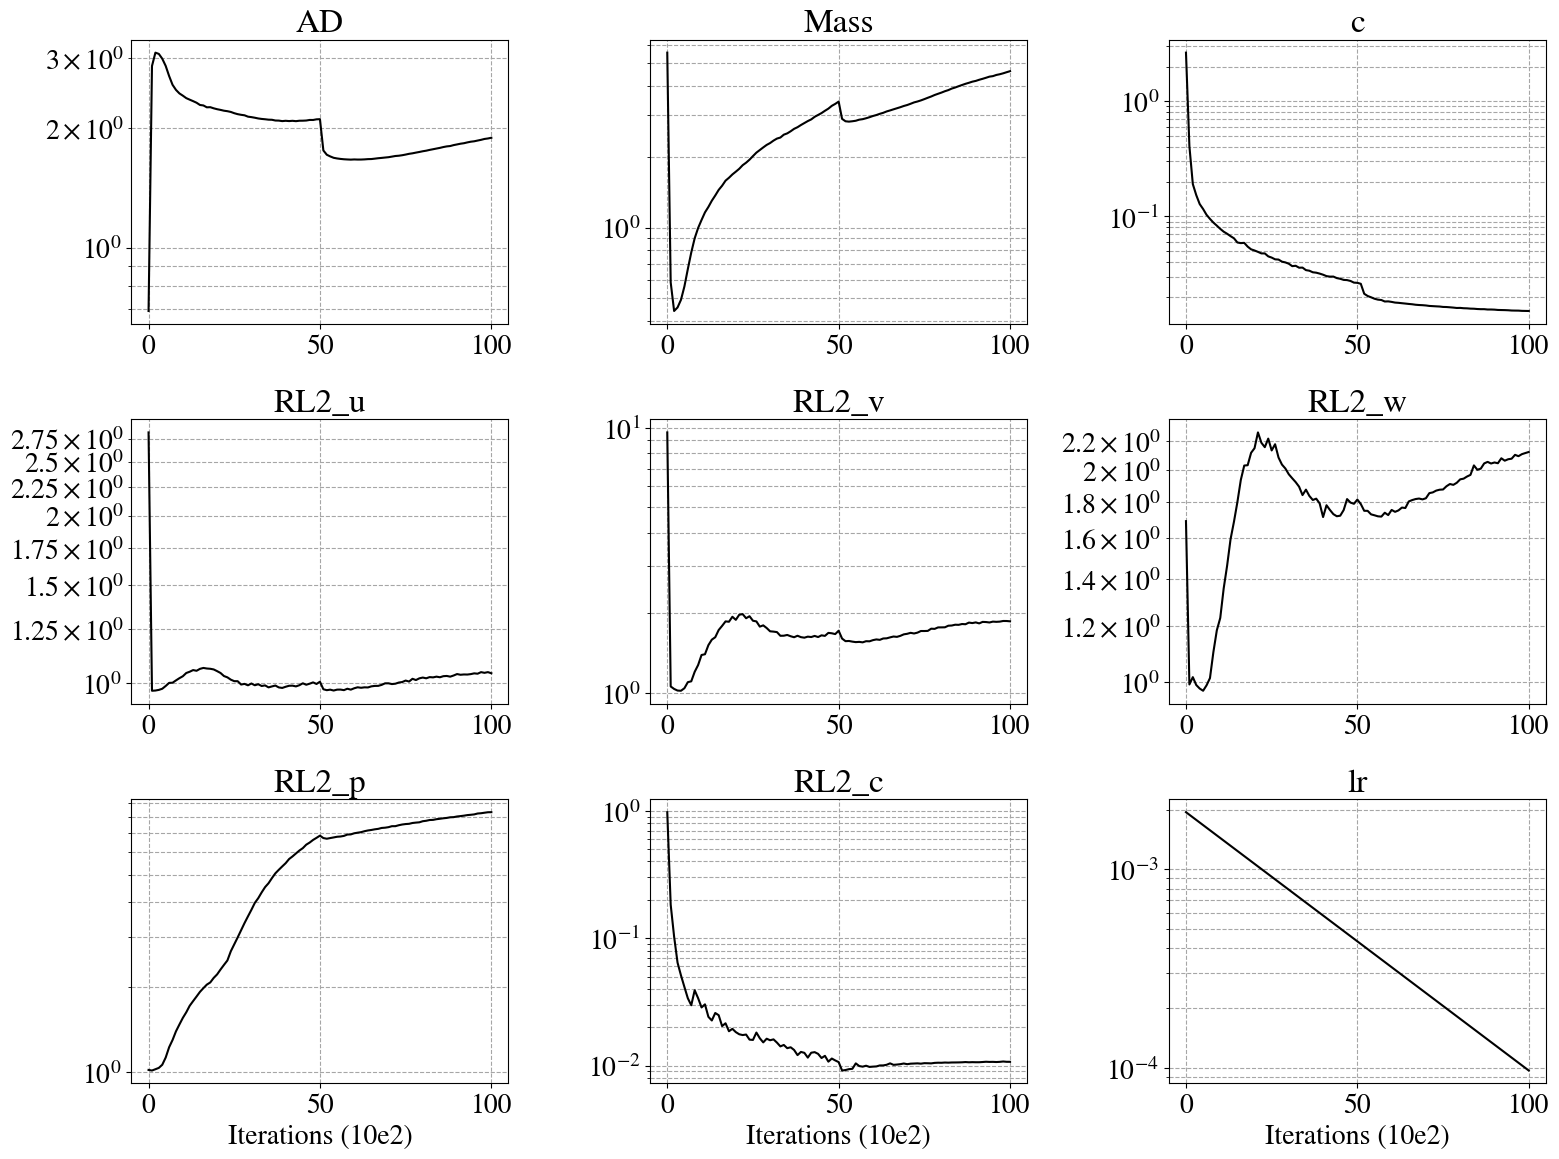

In [ ]:
# Call the function
plot_losses_grid(log_loss)
plt.savefig(result_path + f'Losses.png')
plt.show()


# Plots

In [ ]:
u_fx,v_fx,w_fx,p_fx,c_fx,D_fx,k_fx,c_std_fx  = u_model(params)
# Further computations for errors if any
u_pred  = vmap(u_fx, (0))(dataset['GT'][:,0:layers_ref[0]])[:,None]
v_pred  = vmap(v_fx, (0))(dataset['GT'][:,0:layers_ref[0]])[:,None]
w_pred  = vmap(w_fx, (0))(dataset['GT'][:,0:layers_ref[0]])[:,None]
p_pred  = vmap(p_fx, (0))(dataset['GT'][:,0:layers_ref[0]])[:,None]
c_pred  = vmap(c_fx, (0))(dataset['GT'][:,0:layers_ref[0]])[:,None]
velocity_magnitude = np.sqrt(u_pred**2 + v_pred**2 + w_pred**2)

RL2_c = relative_error2(c_pred, dataset['GT'][:,4:5])
print(f'Relative L2 errors for c:{RL2_c:.4e}')
u_max, u_min = np.max(u_pred), np.min(u_pred)
v_max, v_min = np.max(v_pred), np.min(v_pred)
w_max, w_min = np.max(w_pred), np.min(w_pred)
p_max, p_min = np.max(p_pred), np.min(p_pred)
c_max, c_min = np.max(c_pred), np.min(c_pred)
vmag_max, vmag_min= np.max(velocity_magnitude), np.min(velocity_magnitude)

Relative L2 errors for c:1.0621e-02


In [ ]:
#Arrays
T_star=X_nnf[:,:,0]
X_star=X_nnf[:,:,1]
Y_star=X_nnf[:,:,2]
Z_star=X_nnf[:,:,3]
C_star=X_nnf[:,:,4]

k1=1*10**(-12)#m2W
D1=3.8*10**(-10)#m2/s
k2=1*10**(-16)
D2=2.3*10**(-10)
nu_e=7*10**(-7)
rho=993
h=0.00034 #Maximum length by 100
L_char=h
U_char=0.1#mm/min
D_char=2.4e-10*5#m2/s
U_char=U_char*(1/1000)*(1/60)#m/s
T_char0=np.copy(T_char)
T_char=L_char/U_char
C_char=1/(100/keep_c)
mms=10**3
L_char=L_char*mms
U_char=U_char*mms
print(T_char,L_char,U_char,C_char,D_char)
rec_fact=np.array([[T_char,L_char,L_char,L_char,U_char,U_char,U_char,P_char,C_char]])
print(rec_fact)

204.00000000000003 0.34 0.0016666666666666666 0.009652471709350805 1.2e-09
[[2.04000000e+02 3.40000000e-01 3.40000000e-01 3.40000000e-01
  1.66666667e-03 1.66666667e-03 1.66666667e-03 3.91736667e+01
  9.65247171e-03]]


## Errors

  0%|          | 0/85 [00:00<?, ?it/s]

100%|██████████| 85/85 [00:33<00:00,  2.53it/s]


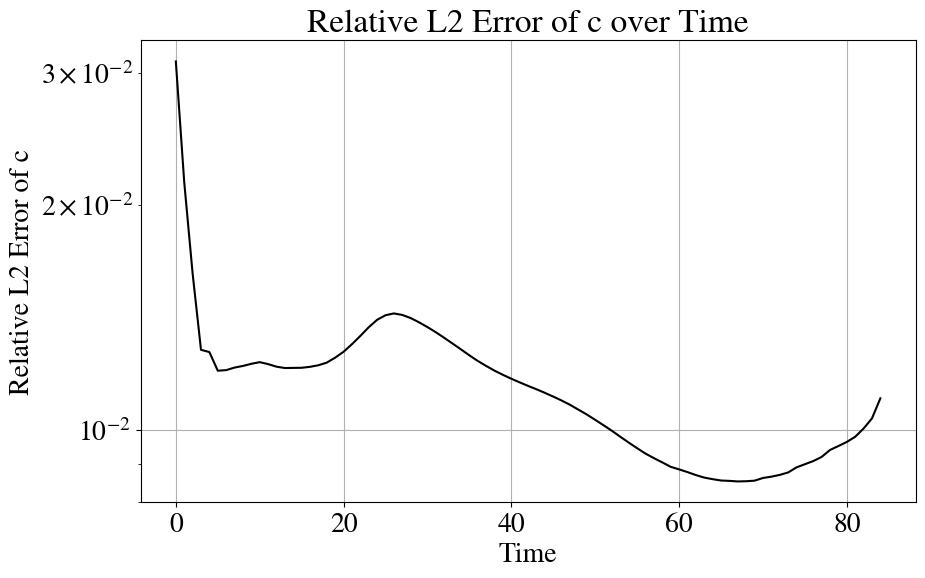

In [ ]:
rec_fact=np.array([[T_char,L_char,L_char,L_char,U_char,U_char,U_char,P_char,C_char]])

Errors_c=[]
min_vals=[]
max_vals=[]
for t__frame_plot in tqdm.tqdm(range(avoid_from_org,len(T_star))):
    snap = np.array([t__frame_plot])
    t_test = T_star[snap,:].T
    x_test = X_star[snap,:].T
    y_test = Y_star[snap,:].T
    z_test = Z_star[snap,:].T
    c_test = C_star[snap,:].T
    X_test=np.hstack((t_test,x_test,y_test,z_test))
    # Further computations for errors if any
    u_pred  = vmap(u_fx, (0))(X_test[:,0:layers_ref[0]])[:,None]
    v_pred  = vmap(v_fx, (0))(X_test[:,0:layers_ref[0]])[:,None]
    w_pred  = vmap(w_fx, (0))(X_test[:,0:layers_ref[0]])[:,None]
    p_pred  = vmap(p_fx, (0))(X_test[:,0:layers_ref[0]])[:,None]
    c_pred  = vmap(c_fx, (0))(X_test[:,0:layers_ref[0]])[:,None]*C_char
    velocity_magnitude = np.sqrt(u_pred**2 + v_pred**2 + w_pred**2)
    uvwpc_pred   = np.hstack((u_pred,v_pred,w_pred,p_pred,c_pred))
    u_pred, v_pred, w_pred, p_pred,c_pred,  =uvwpc_pred[:,0:1],uvwpc_pred[:,1:2],uvwpc_pred[:,2:3],uvwpc_pred[:,3:4],uvwpc_pred[:,4:5]
    error_c = relative_error(c_pred, c_test)
    data_frame=np.hstack((X_test,u_pred, v_pred, w_pred, p_pred,c_pred))
    data_frame=data_frame*rec_fact
    Errors_c.append(error_c)
    min_vals.append(np.min(uvwpc_pred,axis=0))
    max_vals.append(np.max(uvwpc_pred,axis=0))
plt.figure(figsize=(10, 6))
plt.plot(Errors_c, linestyle='-',color='k')
plt.yscale('log')  # Set logarithmic scale for the y-axis
plt.xlabel('Time')
plt.ylabel('Relative L2 Error of c')
plt.title('Relative L2 Error of c over Time')
plt.grid(True)
plt.show()

In [ ]:
print(f'Average RL2 for c over time:{np.mean(Errors_c)}')

Average RL2 for c over time:0.011473623539788994


[-1.1149063e-03 -1.1149063e-03 -9.5395536e+00 -6.2354858e+01
 -8.9819710e+01 -1.3243314e+01]
[ 0.9208419  0.9208419 35.770195  14.355371  15.664689  12.063082 ]


100%|██████████| 1/1 [00:08<00:00,  8.68s/it]


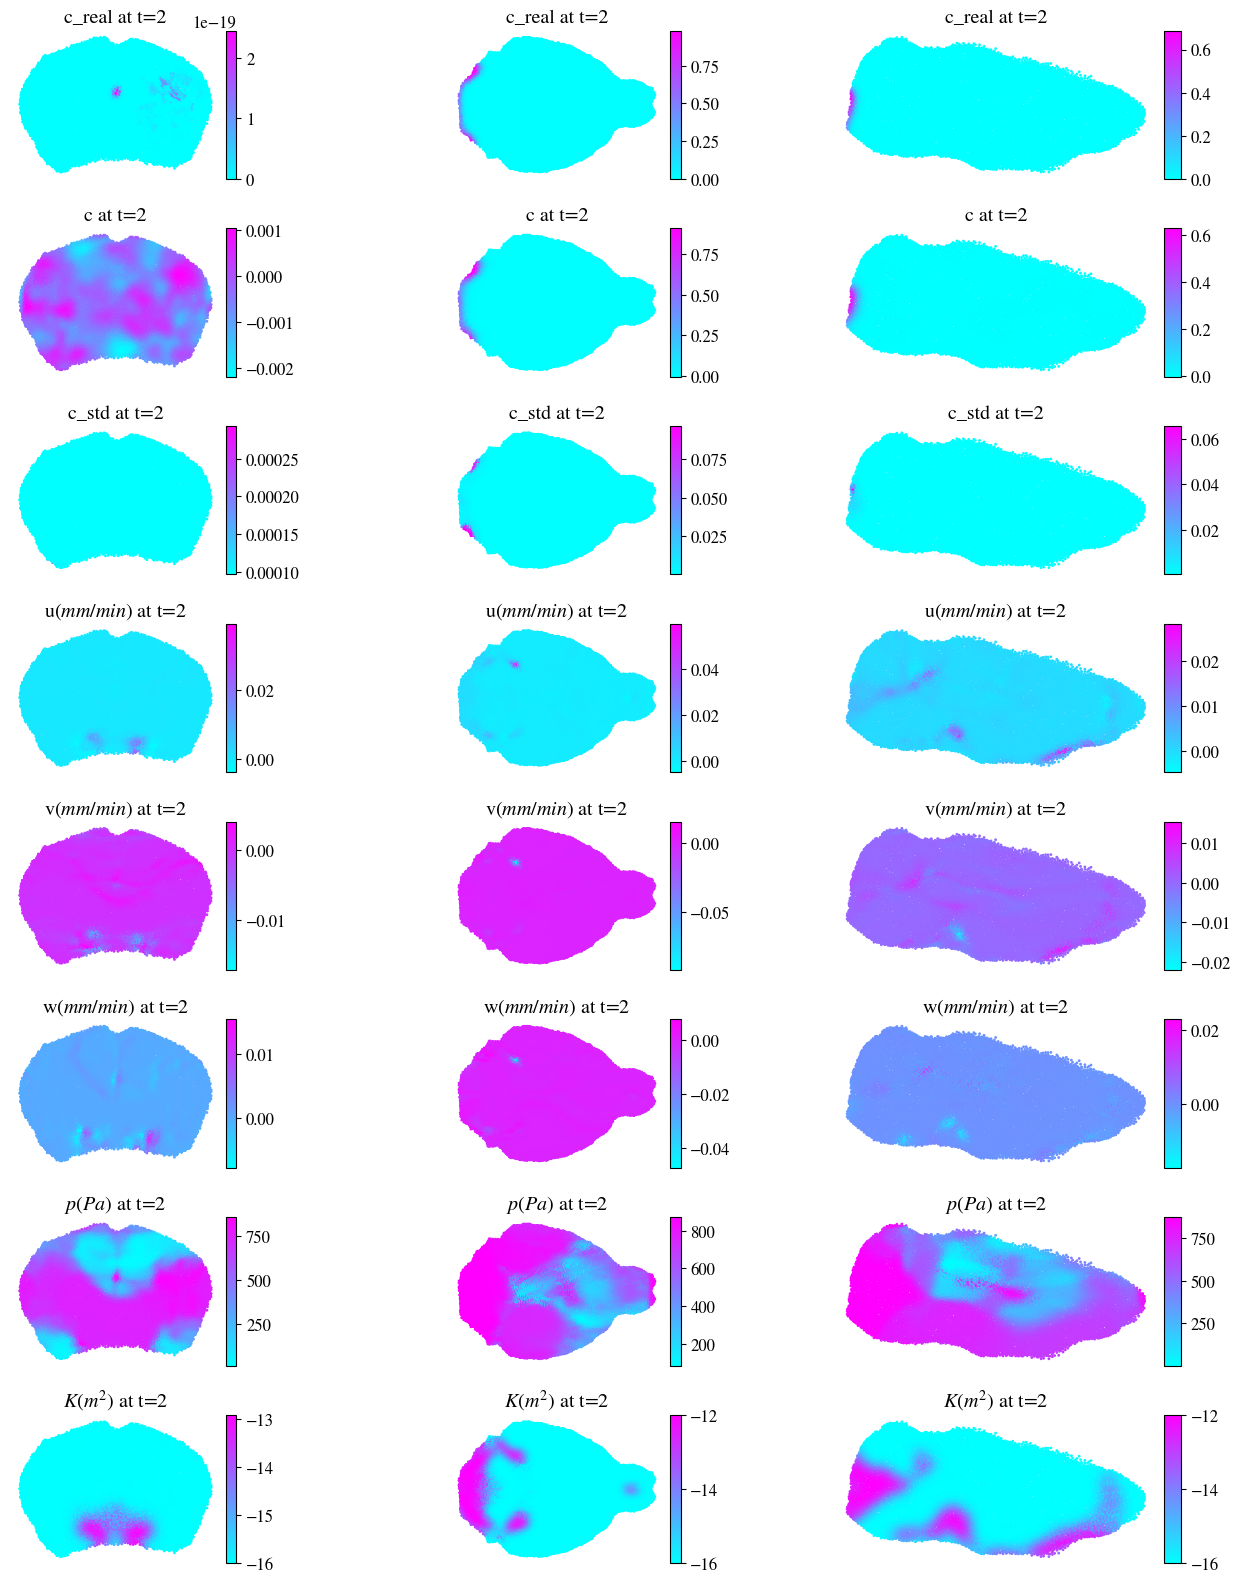

In [ ]:
mpl.rcParams['font.size'] = 12
rec_fact=np.array([[T_char,L_char,L_char,L_char]])
plot=0
# Convert lists of min and max values to numpy arrays for easy indexing
min_vals_arr = np.array(min_vals)
min_vals_arr = np.hstack((min_vals_arr[:,4:5],min_vals_arr[:,4:5],min_vals_arr[:,:4]))
max_vals_arr = np.array(max_vals)
max_vals_arr = np.hstack((max_vals_arr[:,4:5],max_vals_arr[:,4:5],max_vals_arr[:,:4]))


# Compute global min and max for each variable across all frames
global_min = min_vals_arr.min(axis=0)
global_max = max_vals_arr.max(axis=0)
print(global_min)
print(global_max)
start=20
end=start+1
#end=len(T_star)
u_fx,v_fx,w_fx,p_fx,c_fx,D_fx,k_fx,c_std_fx  = u_model(params)

for t__frame_plot in tqdm.tqdm(range(start,end)):
    snap = np.array([t__frame_plot])
    t_test = T_star[snap,:].T
    t_test_k =t_test*0+10
    x_test = X_star[snap,:].T
    y_test = Y_star[snap,:].T
    z_test = Z_star[snap,:].T
    c_test = C_star[snap,:].T
    X_test=np.hstack((t_test,x_test,y_test,z_test))
    X_test_k=np.hstack((t_test_k,x_test,y_test,z_test))

    # Further computations for errors if any
    u_pred  = vmap(u_fx, (0))(X_test[:,0:layers_1[0]])[:,None]*U_char
    v_pred  = vmap(v_fx, (0))(X_test[:,0:layers_1[0]])[:,None]*U_char
    w_pred  = vmap(w_fx, (0))(X_test[:,0:layers_1[0]])[:,None]*U_char
    p_pred  = vmap(p_fx, (0))(X_test[:,0:layers_1[0]])[:,None]*P_char
    p_pred =p_pred-p_pred.min()
    c_pred  = vmap(c_fx, (0))(X_test[:,0:layers_1[0]])[:,None]*C_char
    c_std_pred  = vmap(c_std_fx, (0))(X_test[:,0:layers_1[0]])[:,None]*C_char
    K_pred  = vmap(k_fx, (0))(X_test_k[:,0:layers_ref[0]])[:,None]*k_char
    
    
    velocity_magnitude = np.sqrt(u_pred**2 + v_pred**2 + w_pred**2)
    uvwpc_pred   = np.hstack((u_pred,v_pred,w_pred,p_pred,c_pred,c_std_pred,K_pred))
    u_pred, v_pred, w_pred, p_pred, c_pred,c_std_pred,K_pred = uvwpc_pred[:, 0:1], uvwpc_pred[:, 1:2], uvwpc_pred[:, 2:3], uvwpc_pred[:, 3:4] , uvwpc_pred[:, 4:5], uvwpc_pred[:, 5:6], uvwpc_pred[:, 6:7]
    data_frame = np.hstack((X_test*rec_fact, u_pred, v_pred, w_pred, p_pred, c_pred,c_std_pred,K_pred))


    x_midplane = np.median(x_test)
    y_midplane = np.median(y_test)
    z_midplane = np.median(z_test)

    tolerance = 1.0
    x_midplane_filter = np.abs(x_test - x_midplane) <= tolerance
    y_midplane_filter = np.abs(y_test - y_midplane) <= tolerance
    z_midplane_filter = np.abs(z_test - z_midplane) <= tolerance
    if end>start+1:
        variables = [c_test, c_pred]
        variable_names = ['c_real', 'c']
    variables = [c_test, c_pred,c_std_pred, u_pred, v_pred, w_pred, p_pred,np.log10(K_pred)]
    variable_names = ['c_real', 'c','c_std' ,'u($mm/min$)', 'v($mm/min$)', 'w($mm/min$)', '$p(Pa)$','$K(m^2)$']
    name_image = images_path + f'time:{t__frame_plot / len(T_star):.4f}.png'
    fig = plt.figure(figsize=(14, 2 * len(variables)))

    for i, var in enumerate(variables):
        for j in range(3):
            ax = fig.add_subplot(len(variables), 3, i * 3 + j + 1)
            if j == 0:
                filter = x_midplane_filter
                x, y = z_test, y_test
                xlabel, ylabel = 'Y', 'Z'
            elif j == 1:
                filter = y_midplane_filter
                x, y = x_test, z_test
                xlabel, ylabel = 'X', 'Z'
            else:
                filter = z_midplane_filter
                x, y = x_test, y_test
                xlabel, ylabel = 'X', 'Y'

            #vmin, vmax = global_min[i], global_max[i]  # Use the global min/max values for each variable
            scatter = ax.scatter(x[filter], y[filter], c=var[filter], cmap='cool', s=1)#], vmin=vmin, vmax=vmax)
            ax.set_title(f'{variable_names[i]} at t={t__frame_plot}')
            ax.set_xlabel(xlabel)
            ax.set_ylabel(ylabel)
            ax.axis('equal')
            ax.axis('off')

            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size="5%", pad=0.05)
            plt.colorbar(scatter, cax=cax)

    plt.tight_layout()
    plt.savefig('Steady_high')
    if end>start+1:
        plt.close()


In [ ]:
data_frame = np.hstack((X_test*rec_fact, u_pred, v_pred, w_pred, p_pred, c_pred,c_std_pred,K_pred))
print(data_frame.shape)
np.savetxt('steady_fields_high.txt', data_frame, delimiter=' ', header='t_s x y z_mm u_mm_s v_mm_s w_mm_s P_Pa K_m2')


(148804, 11)


In [ ]:
mpl.rcParams['font.size'] = 12
rec_fact=np.array([[T_char,L_char,L_char,L_char]])
plot=0
# Convert lists of min and max values to numpy arrays for easy indexing
min_vals_arr = np.array(min_vals)
min_vals_arr = np.hstack((min_vals_arr[:,4:5],min_vals_arr[:,4:5],min_vals_arr[:,:4]))
max_vals_arr = np.array(max_vals)
max_vals_arr = np.hstack((max_vals_arr[:,4:5],max_vals_arr[:,4:5],max_vals_arr[:,:4]))


# Compute global min and max for each variable across all frames
global_min = min_vals_arr.min(axis=0)
global_max = max_vals_arr.max(axis=0)
print(global_min)
print(global_max)
plot_all=True
start=0
end=start+1
end=len(T_star)
u_fx,v_fx,w_fx,p_fx,c_fx,D_fx,k_fx,c_std_fx  = u_model(params)
all_results=[]
for t__frame_plot in tqdm.tqdm(range(start,end)):
    snap = np.array([t__frame_plot])
    t_test = T_star[snap,:].T
    t_test_k =t_test*0+10
    x_test = X_star[snap,:].T
    y_test = Y_star[snap,:].T
    z_test = Z_star[snap,:].T
    c_test = C_star[snap,:].T
    X_test=np.hstack((t_test,x_test,y_test,z_test))
    X_test_k=np.hstack((t_test_k,x_test,y_test,z_test))

    # Further computations for errors if any
    c_pred  = vmap(c_fx, (0))(X_test[:,0:layers_1[0]])[:,None]*C_char
    c_std_pred  = vmap(c_std_fx, (0))(X_test[:,0:layers_1[0]])[:,None]*C_char
    

    uvwpc_pred   = np.hstack((c_pred,c_std_pred))
    c_pred,c_std_pred = uvwpc_pred[:, 0:1], uvwpc_pred[:, 1:2]
    data_frame = np.hstack((X_test*rec_fact,c_test, c_pred,c_std_pred))
    all_results.append(data_frame)

    x_midplane = np.median(x_test)
    y_midplane = np.median(y_test)
    z_midplane = np.median(z_test)

    tolerance = 0.05
    x_midplane_filter = np.abs(x_test - x_midplane) <= tolerance
    y_midplane_filter = np.abs(y_test - y_midplane) <= tolerance
    z_midplane_filter = np.abs(z_test - z_midplane) <= tolerance
    variables = [c_test, c_pred,c_std_pred]
    variable_names = ['c_real', 'c','c_std']
    name_image = Video_path + f'C_time:{t__frame_plot / len(T_star):.4f}.png'
    if plot_all:
        fig = plt.figure(figsize=(14, 2 * len(variables)))

        for i, var in enumerate(variables):
            for j in range(3):
                ax = fig.add_subplot(len(variables), 3, i * 3 + j + 1)
                if j == 0:
                    filter = x_midplane_filter
                    x, y = z_test, y_test
                    xlabel, ylabel = 'Y', 'Z'
                elif j == 1:
                    filter = y_midplane_filter
                    x, y = x_test, z_test
                    xlabel, ylabel = 'X', 'Z'
                else:
                    filter = z_midplane_filter
                    x, y = x_test, y_test
                    xlabel, ylabel = 'X', 'Y'

                #vmin, vmax = global_min[i], global_max[i]  # Use the global min/max values for each variable
                scatter = ax.scatter(x[filter], y[filter], c=var[filter], cmap=cmap, s=1)#], vmin=vmin, vmax=vmax)
                ax.set_title(f'{variable_names[i]} at t={t__frame_plot}')
                ax.set_xlabel(xlabel)
                ax.set_ylabel(ylabel)
                ax.axis('equal')
                ax.axis('off')

                divider = make_axes_locatable(ax)
                cax = divider.append_axes("right", size="5%", pad=0.05)
                plt.colorbar(scatter, cax=cax)

        plt.tight_layout()
        plt.savefig(name_image)
        if end>start+1:
            plt.close()


[-1.6354503e-02 -1.6354503e-02 -2.4939079e+01 -2.2894913e+01
 -2.5177929e+01 -5.5146208e+00]
[ 0.8614248  0.8614248 22.165274  17.801327  19.795294  11.775375 ]


100%|██████████| 68/68 [02:44<00:00,  2.41s/it]


# Validate Model

In [ ]:
dataset['Test_crop']=X_test2

In [ ]:
u_fx,v_fx,w_fx,p_fx,c_fx,D_fx,k_fx,c_std_fx  = u_model(params)
# Further computations for errors if any
u_pred  = vmap(u_fx, (0))(dataset['Test_crop'][:,0:layers_1[0]])[:,None]*U_char
v_pred  = vmap(v_fx, (0))(dataset['Test_crop'][:,0:layers_1[0]])[:,None]*U_char
w_pred  = vmap(w_fx, (0))(dataset['Test_crop'][:,0:layers_1[0]])[:,None]*U_char
p_pred  = vmap(p_fx, (0))(dataset['Test_crop'][:,0:layers_1[0]])[:,None]*p_scale*P_char
p_pred  =p_pred-p_pred.min()
c_pred  = vmap(c_fx, (0))(dataset['Test_crop'][:,0:layers_1[0]])[:,None]

velocity_magnitude = np.sqrt(u_pred**2 + v_pred**2 + w_pred**2)

RL2_u = relative_error2(u_pred, dataset['Test_crop'][:,4:5]*U_char)
RL2_v = relative_error2(v_pred, dataset['Test_crop'][:,5:6]*U_char)
RL2_w = relative_error2(w_pred, dataset['Test_crop'][:,6:7]*U_char)

u_max, u_min = np.max(u_pred), np.min(u_pred)
v_max, v_min = np.max(v_pred), np.min(v_pred)
w_max, w_min = np.max(w_pred), np.min(w_pred)
p_max, p_min = np.max(p_pred), np.min(p_pred)
c_max, c_min = np.max(c_pred), np.min(c_pred)
vmag_max, vmag_min= np.max(velocity_magnitude), np.min(velocity_magnitude)
x_test = dataset['Test_crop'][:,1:2]
y_test = dataset['Test_crop'][:,2:3]
z_test = dataset['Test_crop'][:,3:4]
u_test = dataset['Test_crop'][:,4:5]*U_char  
v_test = dataset['Test_crop'][:,5:6]*U_char  
w_test = dataset['Test_crop'][:,6:7]*U_char 
p_test = dataset['Test_crop'][:,7:8]*P_char
p_test  =p_test-p_test.min()
RL2_p = relative_error2(p_pred, p_test)
print(f'Relative L2 errors for u:{RL2_u:.4e} v:{RL2_v:.4e} w:{RL2_w:.4e} p:{RL2_p:.4e}')

V_test = np.sqrt(u_test**2 + v_test**2 + w_test**2)
V_pred = np.sqrt(u_pred**2 + v_pred**2 + w_pred**2)

Relative L2 errors for u:9.8926e-01 v:1.4990e+00 w:1.6486e+00 p:5.0158e+00


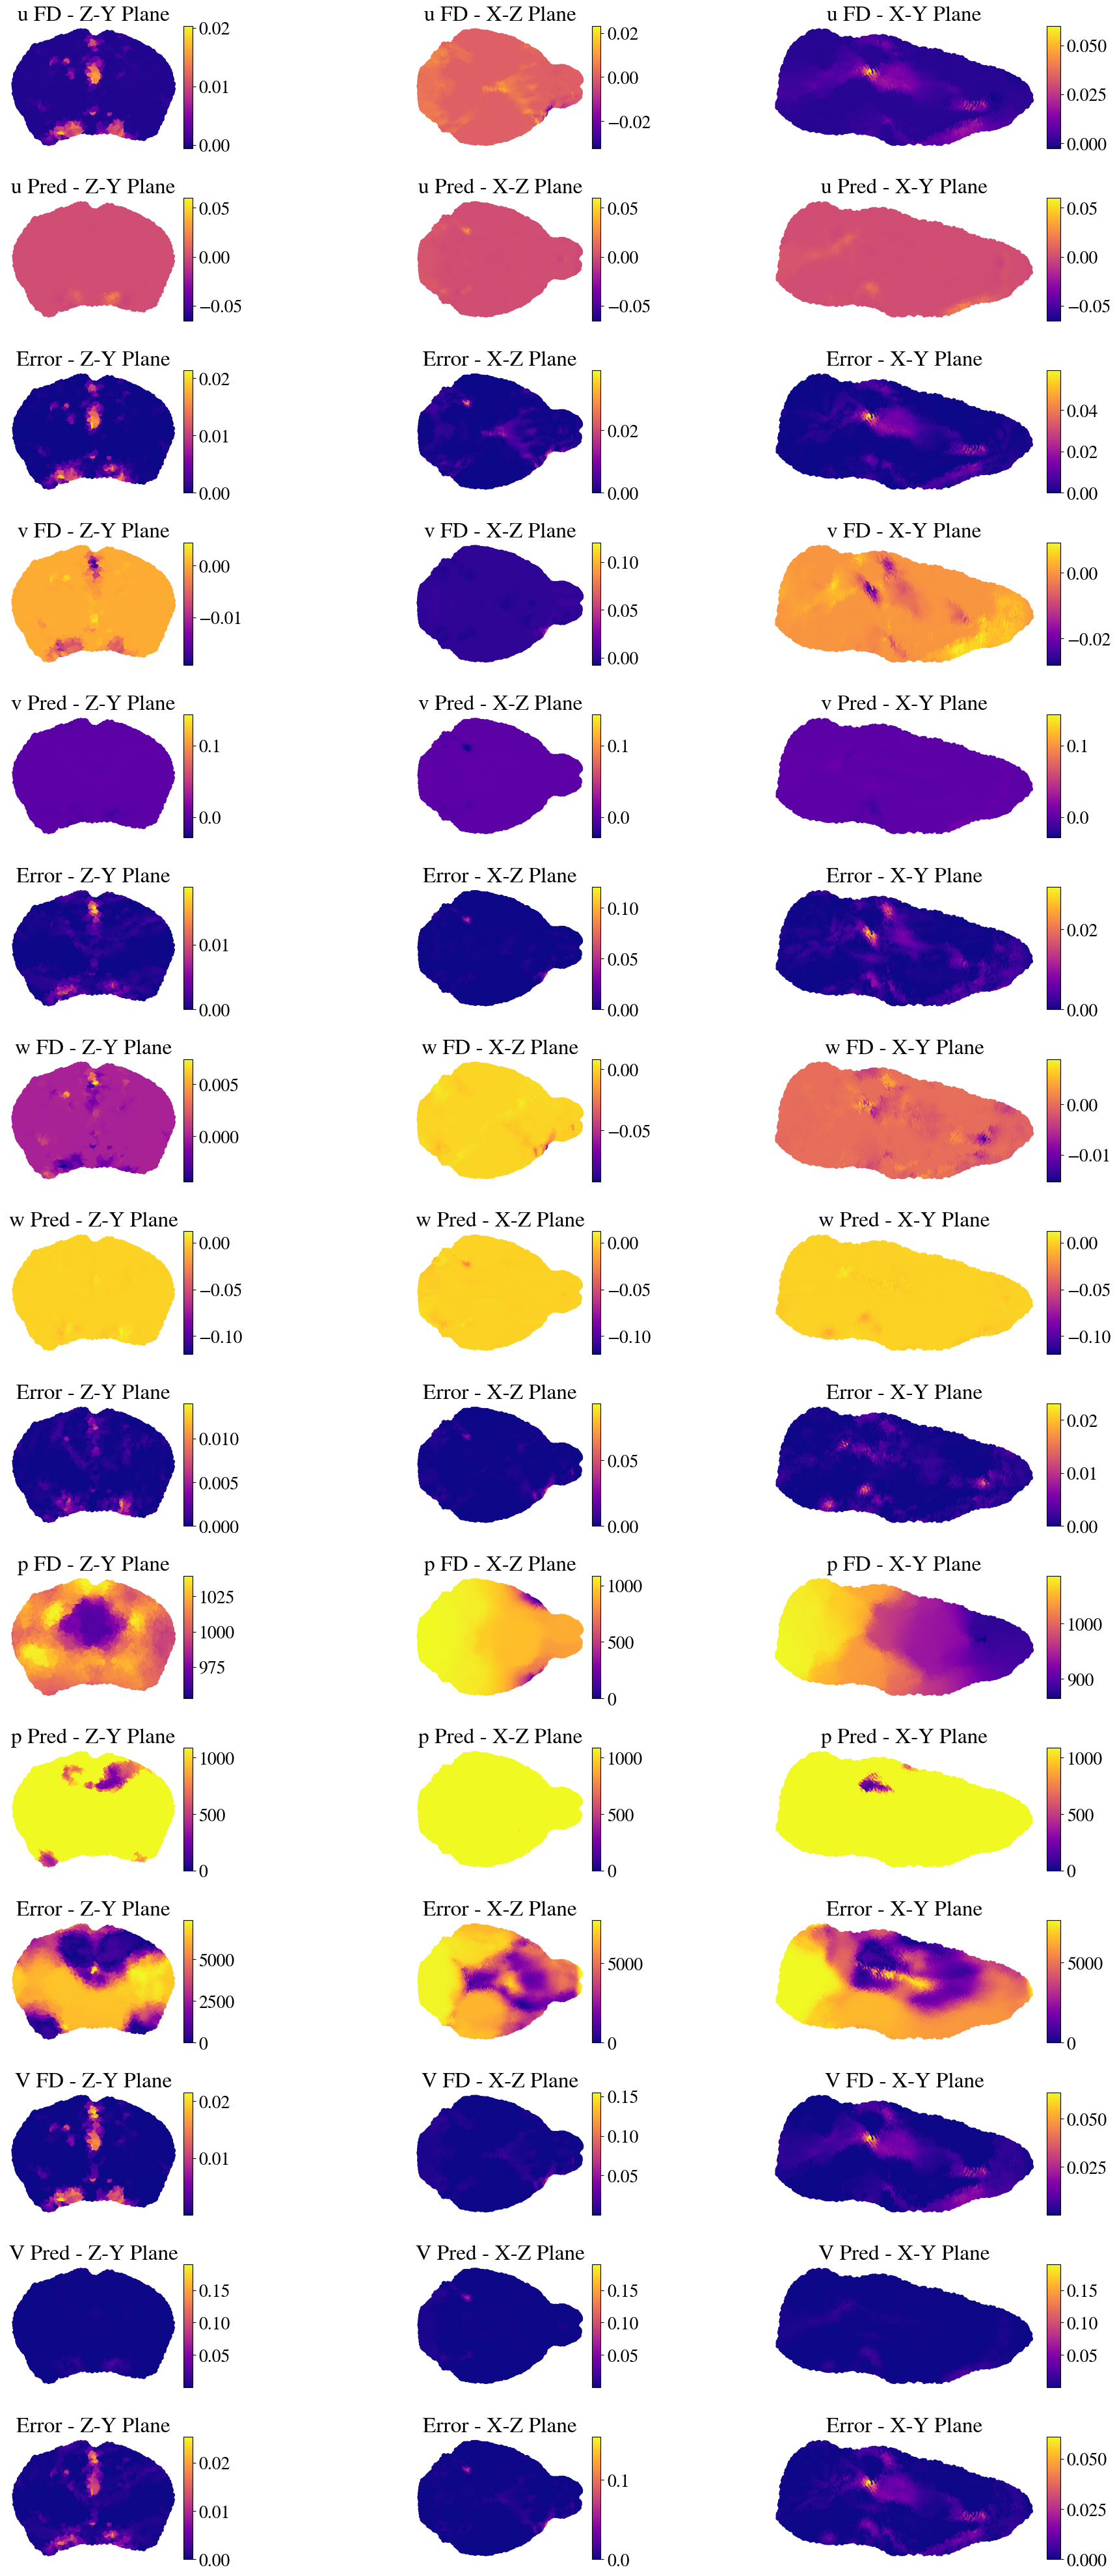

In [ ]:

mpl.rcParams['font.size'] = 20
size_point=20

# Calculate midplane values
x_mid = np.median(x_test)
y_mid = np.median(y_test)
z_mid = np.median(z_test)

# Define tolerance for midplane filtering
tolerance = 0.5

# Create filters for midplane slices
x_filter = np.abs(x_test - x_mid) <= tolerance
y_filter = np.abs(y_test - y_mid) <= tolerance
z_filter = np.abs(z_test - z_mid) <= tolerance

# Prepare the data for plotting
data_pairs = [
    (u_test, u_pred, 'u FD', 'u Pred'),
    (v_test, v_pred, 'v FD', 'v Pred'),
    (w_test, w_pred, 'w FD', 'w Pred'),
    (p_test, p_pred, 'p FD', 'p Pred'),
    (V_test, V_pred, 'V FD', 'V Pred')
]

# Define colormap
cmap = plt.get_cmap('plasma')

# Start plotting
fig, axes = plt.subplots(nrows=15, ncols=3, figsize=(20, 40))#, constrained_layout=True)  # Adjusted for additional rows for error plots

for i, (test_data, pred_data, test_label, pred_label) in enumerate(data_pairs):
    # Compute global vmin and vmax for each pair from the test data
    vmin = np.min(test_data)
    vmax = np.max(test_data)
    error_data = np.abs(test_data - pred_data)  # Calculate absolute error

    for j in range(3):
        if j == 0:  # X Midplane: Plot Y vs Z
            x, y = z_test, y_test
            xlabel, ylabel = 'Z', 'Y'
            filter = x_filter
        elif j == 1:  # Y Midplane: Plot X vs Z
            x, y = x_test, z_test
            xlabel, ylabel = 'X', 'Z'
            filter = y_filter
        else:  # Z Midplane: Plot X vs Y
            x, y = x_test, y_test
            xlabel, ylabel = 'X', 'Y'
            filter = z_filter

        # Index calculation for subplot
        ax_test = axes[i*3, j]
        ax_pred = axes[i*3+1, j]
        ax_error = axes[i*3+2, j]  # Additional axis for error

        # Plot test data
        sc_test = ax_test.scatter(x[filter], y[filter], c=test_data[filter], cmap=cmap)#, vmin=vmin, vmax=vmax,s=size_point)
        ax_test.set_title(f'{test_label} - {xlabel}-{ylabel} Plane')
        ax_test.set_xlabel(xlabel)
        ax_test.set_ylabel(ylabel)
        ax_test.axis('equal')
        ax_test.axis('off')
        divider = make_axes_locatable(ax_test)
        cax_test = divider.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(sc_test, cax=cax_test)

        # Plot predicted data
        sc_pred = ax_pred.scatter(x[filter], y[filter], c=pred_data[filter], cmap=cmap, vmin=vmin, vmax=vmax,s=size_point)
        ax_pred.set_title(f'{pred_label} - {xlabel}-{ylabel} Plane')
        ax_pred.set_xlabel(xlabel)
        ax_pred.set_ylabel(ylabel)
        ax_pred.axis('equal')
        ax_pred.axis('off')
        divider = make_axes_locatable(ax_pred)
        cax_pred = divider.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(sc_pred, cax=cax_pred)

        # Plot error data
        sc_error = ax_error.scatter(x[filter], y[filter], c=error_data[filter], cmap=cmap, vmin=0,s=size_point)#, vmax=vmax-vmin)
        ax_error.set_title(f'Error - {xlabel}-{ylabel} Plane')
        ax_error.set_xlabel(xlabel)
        ax_error.set_ylabel(ylabel)
        ax_error.axis('equal')
        ax_error.axis('off')
        divider = make_axes_locatable(ax_error)
        cax_error = divider.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(sc_error, cax=cax_error)
plt.tight_layout()
plt.show()

# Save or show the figure


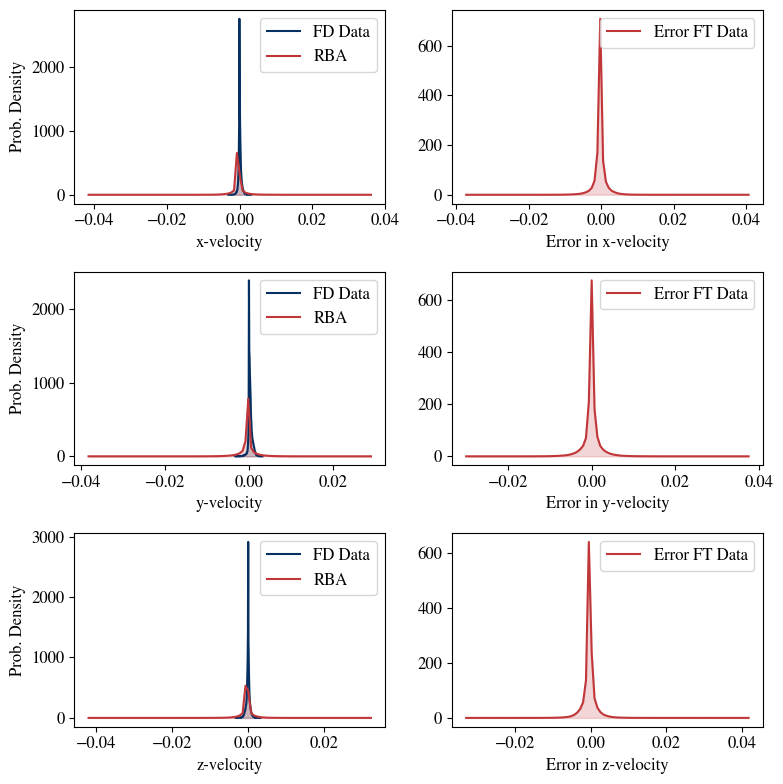

In [ ]:

def get_pdf(u_hist, bins=30):
    hist, bins = np.histogram(u_hist, bins=bins, density=True)
    prob_density = hist
    return prob_density, bins
def get_colors_plot(cmap='RdBu', n_colors=2):
    
    cmap = plt.get_cmap(cmap)
    colors = [cmap(i) for i in np.linspace(0, 1, n_colors)]
    return colors
def plot_pdf_fields_with_error(datasets, field_names, colors, bins=100, figsize=(8, 8)):
    num_fields = len(datasets)
    fig, axs = plt.subplots(num_fields, 2, figsize=figsize)  # 3 columns for data, RBA, and error

    for i, ((data_piv, data_aiv), field_name) in enumerate(zip(datasets, field_names)):
        prob_density_piv, bins_piv = get_pdf(data_piv, bins=bins)
        prob_density_aiv, bins_aiv = get_pdf(data_aiv, bins=bins)
        error = data_piv - data_aiv
        prob_density_error, bins_error = get_pdf(error, bins=bins)

        # Plotting data
        axs[i, 0].plot(bins_piv[:-1], prob_density_piv, color=colors[0], label=f'FD Data')
        axs[i, 0].fill_between(bins_piv[:-1], prob_density_piv, color=colors[0], alpha=0.2)
        axs[i, 0].set_xlabel(f'{field_name}')
        axs[i, 0].plot(bins_aiv[:-1], prob_density_aiv, color=colors[-2], label='RBA')
        axs[i, 0].fill_between(bins_aiv[:-1], prob_density_aiv, color=colors[-2], alpha=0.2)
        axs[i, 0].set_xlabel(f'{field_name}')
        axs[i, 0].set_ylabel('Prob. Density')
        axs[i, 0].legend(loc='upper right')
        axs[i, 0].set_yscale('log')  # Apply log scale to the y-axis

        # Plotting error
        axs[i, 1].plot(bins_error[:-1], prob_density_error, color=colors[-2], label='Error FT Data')
        axs[i, 1].fill_between(bins_error[:-1], prob_density_error, color=colors[-2], alpha=0.2)
        axs[i, 1].set_xlabel(f'Error in {field_name}')
        axs[i, 1].legend(loc='upper right')
        axs[i, 1].set_yscale('log')  # Apply log scale to the y-axis

    plt.tight_layout()
    return fig


# Extracting and reshaping data
u_piv_hist = np.array(jax.device_get(dataset['Test_crop'][:,4:5])*U_char).reshape(-1)
u_aiv_hist = np.array(jax.device_get(u_pred)).reshape(-1)
v_piv_hist = np.array(jax.device_get(dataset['Test_crop'][:,5:6])*U_char).reshape(-1)
v_aiv_hist = np.array(jax.device_get(v_pred)).reshape(-1)
w_piv_hist = np.array(jax.device_get(dataset['Test_crop'][:,6:7])*U_char).reshape(-1)
w_aiv_hist = np.array(jax.device_get(w_pred)).reshape(-1)  # Assuming w_pred is defined

bins = 40

# Calculating probability densities
prob_density_u_piv, bins_u_piv = get_pdf(u_piv_hist, bins=bins)
prob_density_u_aiv, bins_u_aiv = get_pdf(u_aiv_hist, bins=bins)
prob_density_v_piv, bins_v_piv = get_pdf(v_piv_hist, bins=bins)
prob_density_v_aiv, bins_v_aiv = get_pdf(v_aiv_hist, bins=bins)
prob_density_w_piv, bins_w_piv = get_pdf(w_piv_hist, bins=bins)
prob_density_w_aiv, bins_w_aiv = get_pdf(w_aiv_hist, bins=bins)


colors = get_colors_plot(cmap='RdBu_r', n_colors=8)
datasets = [(u_piv_hist, u_aiv_hist), (v_piv_hist, v_aiv_hist), 
            (w_piv_hist, w_aiv_hist)]
field_names = ['x-velocity', 'y-velocity', 'z-velocity', 'T']
mpl.rcParams['font.size'] = 12

fig = plot_pdf_fields_with_error(datasets, field_names, colors)

plt.savefig(result_path + '/AIV-Prob_dist_epochs.png')
plt.show()

